# Phi-Tiny (SIQA): analysis of layer importance proxy metrics

Adjacent layer metrics vs accuracy drop analysis.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re, os

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
num_layers = 32
print('OK')

# Base directory of the repository (parent of analysis/)
SCRIPT_DIR = os.path.abspath('')
BASE_DIR = os.path.abspath(os.path.join(SCRIPT_DIR, ".."))


OK


## 1. Load accuracy drop data

In [12]:
accuracy_df = pd.read_csv(os.path.join(BASE_DIR, "siqa", "phi-tiny metrics + layers", "accuracy data", "ablations.csv"))
accuracy_drops = [{'Layer': int(row['Layer']), 'Accuracy_Drop': float(row['Ablation_Drop'])} for _, row in accuracy_df.iterrows()]
df_acc = pd.DataFrame(accuracy_drops)
df_acc['Abs_Drop'] = df_acc['Accuracy_Drop'].abs()
print(f'Loaded {len(df_acc)} layers')
df_acc

Loaded 32 layers


,Layer,Accuracy_Drop,Abs_Drop
0,0,-56.6,56.6
1,1,-5.2,5.2
2,2,-0.8,0.8
3,3,-24.0,24.0
4,4,-4.4,4.4
5,5,-7.0,7.0
6,6,-1.8,1.8
7,7,-2.2,2.2
8,8,-2.8,2.8
9,9,-6.4,6.4


## 2. Load metrics

In [13]:
metrics_dir = os.path.join(BASE_DIR, "siqa", "phi-tiny metrics + layers", "metric data", "metrics")
matrix_metric_files = {
    'MSE': 'metric_01_MSE.csv',
    'Cosine_Dist': 'metric_02_Cosine_Distance.csv',
    'Res_Contrib': 'metric_03_Residual_Contribution.csv',
    'CKA': 'metric_04_CKA.csv',
    'L1_Dist': 'metric_05_L1_Distance.csv',
    'L_Inf': 'metric_06_L_Infinity.csv',
    'Var_Ratio': 'metric_07_Variance_Ratio.csv',
    'Pearson': 'metric_08_Pearson_Correlation.csv',
}
adjacent_metrics = {}
for metric_name, filename in matrix_metric_files.items():
    df_matrix = pd.read_csv(os.path.join(metrics_dir, filename), index_col=0)
    values = []
    for i in range(num_layers):
        if i < num_layers - 1:
            values.append(df_matrix.iloc[i, i + 1])
        else:
            values.append(df_matrix.iloc[i - 1, i])
    adjacent_metrics[metric_name] = values
    print(f'{metric_name}: OK')

df_entropy = pd.read_csv(os.path.join(metrics_dir, 'metric_09_Router_Entropy.csv'))
adjacent_metrics['Router_Entropy'] = df_entropy['Avg_Router_Entropy'].tolist()
print(f'Router_Entropy: OK')

MSE: OK
Cosine_Dist: OK
Res_Contrib: OK
CKA: OK
L1_Dist: OK
L_Inf: OK
Var_Ratio: OK
Pearson: OK
Router_Entropy: OK


## 3. Proxy metric (Qwen coefficients transferred to Phi-Tiny)

In [14]:
proxy_coefficients = {
    'L1_Dist': 0.7280, 'Cosine_Dist': -0.6287, 'Pearson': 0.6283,
    'L_Inf': 0.4512, 'MSE': 0.2983, 'Router_Entropy': 0.1063,
    'Res_Contrib': 0.0540, 'Var_Ratio': 0.0400, 'CKA': 0.0205,
}
normalized_metrics = {}
for name, values in adjacent_metrics.items():
    arr = np.array(values, dtype=float)
    std_val = arr.std()
    normalized_metrics[name] = (arr - arr.mean()) / std_val if std_val > 0 else arr - arr.mean()

proxy_values = np.zeros(num_layers)
for name, coeff in proxy_coefficients.items():
    proxy_values += coeff * normalized_metrics[name]
adjacent_metrics['Proxy_Metric'] = proxy_values.tolist()
print('Proxy metric computed (Qwen coefficients)')

Proxy metric computed (Qwen coefficients)


## 3.1 Trained proxy metrics (Poly, Lasso)

In [15]:
from sklearn.preprocessing import PolynomialFeatures

# Build raw features in the same order as train_poly.py
feature_order_poly = ['MSE', 'Cosine_Dist', 'Res_Contrib', 'CKA', 'L1_Dist',
                      'L_Inf', 'Var_Ratio', 'Pearson', 'Router_Entropy']
X_raw = np.column_stack([np.array(adjacent_metrics[f], dtype=float) for f in feature_order_poly])

poly_transformer = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_transformer.fit_transform(X_raw)
poly_feat_names = list(poly_transformer.get_feature_names_out(feature_order_poly))

# Z-normalize
X_poly_norm = (X_poly - X_poly.mean(axis=0)) / (X_poly.std(axis=0) + 1e-8)

# Weights from train_poly_out.txt (sorted by abs weight)
poly_weights = {
    'CKA L1_Dist': 0.2526, 'Cosine_Dist CKA': -0.2474,
    'Cosine_Dist Pearson': -0.1643, 'L1_Dist Pearson': 0.1235,
    'CKA L_Inf': 0.1176, 'L_Inf Pearson': 0.1139,
    'Pearson^2': 0.1013, 'CKA^2': 0.0941, 'CKA Pearson': 0.0914,
    'L_Inf': 0.0773, 'L_Inf Router_Entropy': 0.0772,
    'Pearson Router_Entropy': 0.0753, 'Cosine_Dist': -0.0751,
    'Pearson': 0.0750, 'Cosine_Dist Router_Entropy': -0.0750,
    'Router_Entropy^2': 0.0685, 'Router_Entropy': 0.0683,
    'L1_Dist': 0.0674, 'L1_Dist Router_Entropy': 0.0674,
    'CKA Router_Entropy': 0.0642, 'CKA': 0.0640,
    'L_Inf^2': 0.0476, 'MSE CKA': 0.0417, 'MSE Pearson': 0.0285,
    'Res_Contrib CKA': -0.0259, 'Cosine_Dist L1_Dist': 0.0236,
    'MSE': 0.0226, 'MSE Router_Entropy': 0.0226,
    'L_Inf Var_Ratio': 0.0225, 'Cosine_Dist L_Inf': 0.0215,
    'L1_Dist L_Inf': 0.0214, 'Res_Contrib L1_Dist': 0.0212,
    'L1_Dist^2': 0.0207, 'Res_Contrib L_Inf': 0.0206,
    'L1_Dist Var_Ratio': 0.0205, 'Res_Contrib Pearson': -0.0201,
    'MSE Var_Ratio': 0.0186, 'MSE L_Inf': 0.0184,
    'MSE Cosine_Dist': 0.0178, 'MSE Res_Contrib': 0.0174,
    'MSE L1_Dist': 0.0171, 'MSE^2': 0.0169,
    'CKA Var_Ratio': 0.0166, 'Cosine_Dist^2': -0.0151,
    'Res_Contrib^2': 0.0120, 'Var_Ratio^2': -0.0091,
    'Res_Contrib': -0.0058, 'Res_Contrib Router_Entropy': -0.0058,
    'Cosine_Dist Var_Ratio': -0.0053, 'Res_Contrib Var_Ratio': 0.0053,
    'Var_Ratio': -0.0051, 'Var_Ratio Router_Entropy': -0.0051,
    'Var_Ratio Pearson': -0.0047, 'Cosine_Dist Res_Contrib': 0.0039,
}

poly_proxy = np.zeros(num_layers)
for feat_name, w in poly_weights.items():
    idx = poly_feat_names.index(feat_name)
    poly_proxy += w * X_poly_norm[:, idx]
adjacent_metrics['Poly_Proxy'] = poly_proxy.tolist()
print(f'Poly proxy computed ({len(poly_weights)} polynomial features)')

Poly proxy computed (54 polynomial features)


In [16]:
# Lasso proxy — uses prev/next/first/last/mean/std features from full matrices
# Weights from train+test_lasso_qwen_out.txt (only 6 non-zero features selected by Lasso)
lasso_feature_specs = {
    'Cosine_Dist_first': ('metric_02_Cosine_Distance.csv', 'first'),
    'Var_Ratio_prev':    ('metric_07_Variance_Ratio.csv',  'prev'),
    'Cosine_Dist_last':  ('metric_02_Cosine_Distance.csv', 'last'),
    'Cosine_Dist_std':   ('metric_02_Cosine_Distance.csv', 'std'),
    'L_Inf_next':        ('metric_06_L_Infinity.csv',      'next'),
    'Pearson_last':      ('metric_08_Pearson_Correlation.csv', 'last'),
}
lasso_weights = {
    'Cosine_Dist_first':  8.865018,
    'Var_Ratio_prev':     5.345146,
    'Cosine_Dist_last':  -5.328091,
    'Cosine_Dist_std':    4.972951,
    'L_Inf_next':         1.218786,
    'Pearson_last':       0.145107,
}

lasso_raw_features = {}
for feat_name, (csv_file, agg_type) in lasso_feature_specs.items():
    df_mat = pd.read_csv(os.path.join(metrics_dir, csv_file), index_col=0)
    matrix = df_mat.values
    vals = np.zeros(num_layers)
    for i in range(num_layers):
        if agg_type == 'prev':
            vals[i] = matrix[i, i - 1] if i > 0 else matrix[i, i]
        elif agg_type == 'next':
            vals[i] = matrix[i, i + 1] if i < num_layers - 1 else matrix[i, i]
        elif agg_type == 'first':
            vals[i] = matrix[i, 0]
        elif agg_type == 'last':
            vals[i] = matrix[i, num_layers - 1]
        elif agg_type == 'mean':
            vals[i] = np.mean(matrix[i, :])
        elif agg_type == 'std':
            vals[i] = np.std(matrix[i, :])
    lasso_raw_features[feat_name] = vals

# Z-normalize and apply weights
lasso_proxy = np.zeros(num_layers)
for feat_name, w in lasso_weights.items():
    arr = lasso_raw_features[feat_name]
    arr_norm = (arr - arr.mean()) / (arr.std() + 1e-8)
    lasso_proxy += w * arr_norm
adjacent_metrics['Lasso_Proxy'] = lasso_proxy.tolist()
print('Lasso proxy computed (6 features selected by LassoCV)')

Lasso proxy computed (6 features selected by LassoCV)


In [17]:
# Lasso Rank proxy — trained on RANKS instead of raw drops
# Weights from lasso_rank_out.txt (7 features selected by LassoCV)
lasso_rank_specs = {
    'Cosine_Dist_std':   ('metric_02_Cosine_Distance.csv', 'std'),
    'Cosine_Dist_first': ('metric_02_Cosine_Distance.csv', 'first'),
    'Cosine_Dist_last':  ('metric_02_Cosine_Distance.csv', 'last'),
    'Var_Ratio_prev':    ('metric_07_Variance_Ratio.csv',  'prev'),
    'L_Inf_next':        ('metric_06_L_Infinity.csv',      'next'),
    'Pearson_last':      ('metric_08_Pearson_Correlation.csv', 'last'),
    'Pearson_first':     ('metric_08_Pearson_Correlation.csv', 'first'),
}
lasso_rank_weights = {
    'Cosine_Dist_std':    2.233731,
    'Cosine_Dist_first':  1.974709,
    'Cosine_Dist_last':  -1.770079,
    'Var_Ratio_prev':     0.891725,
    'L_Inf_next':         0.355225,
    'Pearson_last':       0.080087,
    'Pearson_first':     -0.000008,
}

lasso_rank_raw = {}
for feat_name, (csv_file, agg_type) in lasso_rank_specs.items():
    # Reuse already-loaded features if same key exists from Lasso
    if feat_name in lasso_raw_features:
        lasso_rank_raw[feat_name] = lasso_raw_features[feat_name]
        continue
    df_mat = pd.read_csv(os.path.join(metrics_dir, csv_file), index_col=0)
    matrix = df_mat.values
    vals = np.zeros(num_layers)
    for i in range(num_layers):
        if agg_type == 'prev':
            vals[i] = matrix[i, i - 1] if i > 0 else matrix[i, i]
        elif agg_type == 'next':
            vals[i] = matrix[i, i + 1] if i < num_layers - 1 else matrix[i, i]
        elif agg_type == 'first':
            vals[i] = matrix[i, 0]
        elif agg_type == 'last':
            vals[i] = matrix[i, num_layers - 1]
        elif agg_type == 'std':
            vals[i] = np.std(matrix[i, :])
    lasso_rank_raw[feat_name] = vals

lasso_rank_proxy = np.zeros(num_layers)
for feat_name, w in lasso_rank_weights.items():
    arr = lasso_rank_raw[feat_name]
    arr_norm = (arr - arr.mean()) / (arr.std() + 1e-8)
    lasso_rank_proxy += w * arr_norm
adjacent_metrics['Lasso_Rank_Proxy'] = lasso_rank_proxy.tolist()
print('Lasso Rank proxy computed (7 features, trained on ranks)')

Lasso Rank proxy computed (7 features, trained on ranks)


## 4. Combined DataFrame

In [18]:
df_all = df_acc.copy()
for metric_name, values in adjacent_metrics.items():
    df_all[metric_name] = values
all_metrics = list(matrix_metric_files.keys()) + ['Router_Entropy', 'Proxy_Metric', 'Poly_Proxy', 'Lasso_Proxy', 'Lasso_Rank_Proxy']
df_all

,Layer,Accuracy_Drop,Abs_Drop,MSE,Cosine_Dist,Res_Contrib,CKA,L1_Dist,L_Inf,Var_Ratio,Pearson,Router_Entropy,Proxy_Metric,Poly_Proxy,Lasso_Proxy,Lasso_Rank_Proxy
0,0,-56.6,56.6,0.003125,0.140221,0.983019,0.825981,0.009754,7.640972,12.039022,0.859776,2.763257,-1.397845,-1.107173,-37.897331,-9.741962
1,1,-5.2,5.2,0.000246,0.104613,0.629886,0.955924,0.010118,0.890091,1.329784,0.895386,2.768395,-0.988695,-0.641229,-37.976534,-8.926287
2,2,-0.8,0.8,5.061528,0.164193,7.034919,0.060005,0.043132,526.332031,2011.771270,0.835814,2.766464,1.768729,0.596145,-24.144361,-5.818762
3,3,-24.0,24.0,0.001624,0.250021,1.069865,0.999988,0.028303,2.501156,1.007610,0.749971,2.404341,-2.705990,-1.843602,-34.569803,-8.648334
4,4,-4.4,4.4,0.199796,0.454664,3.878422,0.985090,0.061747,54.413854,1.234988,0.545329,2.754437,-4.675962,-2.984622,-25.154108,-8.134255
5,5,-7.0,7.0,0.004574,0.156895,0.579659,0.999924,0.046704,3.595434,0.986980,0.843087,2.691096,-1.478307,-0.912059,-21.913574,-7.812538
6,6,-1.8,1.8,0.007559,0.163041,0.638949,0.999746,0.055972,4.390789,1.000525,0.836941,2.539023,-1.530183,-0.984540,-16.126669,-6.134406
7,7,-2.2,2.2,0.012706,0.133903,0.592325,0.999384,0.068157,7.298953,1.011235,0.866094,2.477349,-1.125164,-0.707971,-10.867236,-4.343541
8,8,-2.8,2.8,0.035729,0.107319,0.550882,0.999846,0.088436,5.615088,1.004775,0.892678,1.447723,-0.856067,-0.758690,-7.560679,-3.215673
9,9,-6.4,6.4,5.698731,0.135644,1.373099,0.576237,0.153357,310.166366,1.956598,0.864356,1.452857,1.293017,0.287461,-3.486935,-2.025946


## 5. Line plots: metric vs accuracy drop + log-log

In [19]:
def plot_metric_vs_accuracy(df, metric_name, title_suffix=''):
    fig, ax1 = plt.subplots(figsize=(20, 6))
    layers = df['Layer'].values
    ax1.plot(layers, df['Abs_Drop'], 'o-', color='#e74c3c', linewidth=2, markersize=6, label='Accuracy Drop (%)', zorder=5)
    ax1.set_xlabel('Layer'); ax1.set_ylabel('Accuracy Drop (%)', color='#e74c3c')
    ax1.tick_params(axis='y', labelcolor='#e74c3c'); ax1.set_xticks(layers); ax1.grid(True, alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(layers, df[metric_name], 's-', color='#3498db', linewidth=2, markersize=6, label=metric_name, zorder=5)
    ax2.set_ylabel(metric_name, color='#3498db'); ax2.tick_params(axis='y', labelcolor='#3498db')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.title(f'Phi-Tiny SIQA: {metric_name} vs Accuracy Drop{title_suffix}'); plt.tight_layout(); plt.show()

def plot_loglog(df, metric_name, title_suffix=''):
    fig, ax = plt.subplots(figsize=(8, 8))
    x = df[metric_name].values.astype(float); y = df['Abs_Drop'].values.astype(float)
    mask = (x > 0) & (y > 0)
    x_pos, y_pos, layers_pos = x[mask], y[mask], df['Layer'].values[mask]
    if len(x_pos) < 2: print(f'{metric_name}: not enough data for log-log'); plt.close(); return
    ax.scatter(x_pos, y_pos, s=80, c='#2c3e50', alpha=0.8, zorder=5)
    for i, lbl in enumerate(layers_pos):
        ax.annotate(str(lbl), (x_pos[i], y_pos[i]), textcoords='offset points', xytext=(5, 5), fontsize=8, alpha=0.7)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(f'{metric_name} (log)'); ax.set_ylabel('Accuracy Drop, % (log)')
    ax.set_title(f'Phi-Tiny Log-Log: {metric_name} vs Accuracy Drop{title_suffix}')
    ax.grid(True, alpha=0.3, which='both')
    log_x, log_y = np.log10(x_pos), np.log10(y_pos)
    slope, intercept, r, p, se = stats.linregress(log_x, log_y)
    x_fit = np.logspace(np.log10(x_pos.min()), np.log10(x_pos.max()), 100)
    ax.plot(x_fit, 10**(slope*np.log10(x_fit)+intercept), '--', color='#e74c3c', linewidth=1.5, alpha=0.7, label=f'slope={slope:.2f}, R2={r**2:.3f}')
    ax.legend(); plt.tight_layout(); plt.show()

print('Plot functions ready')

Plot functions ready


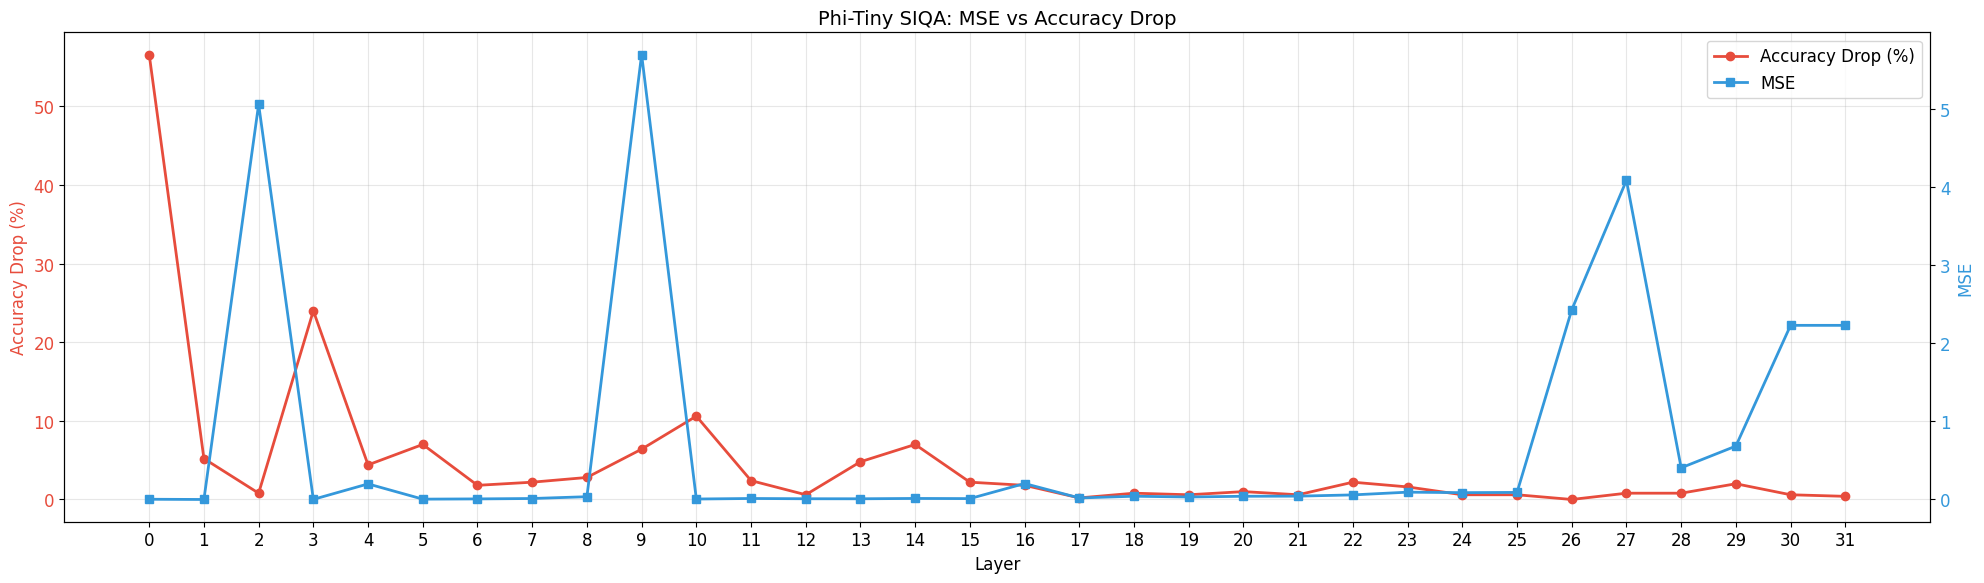

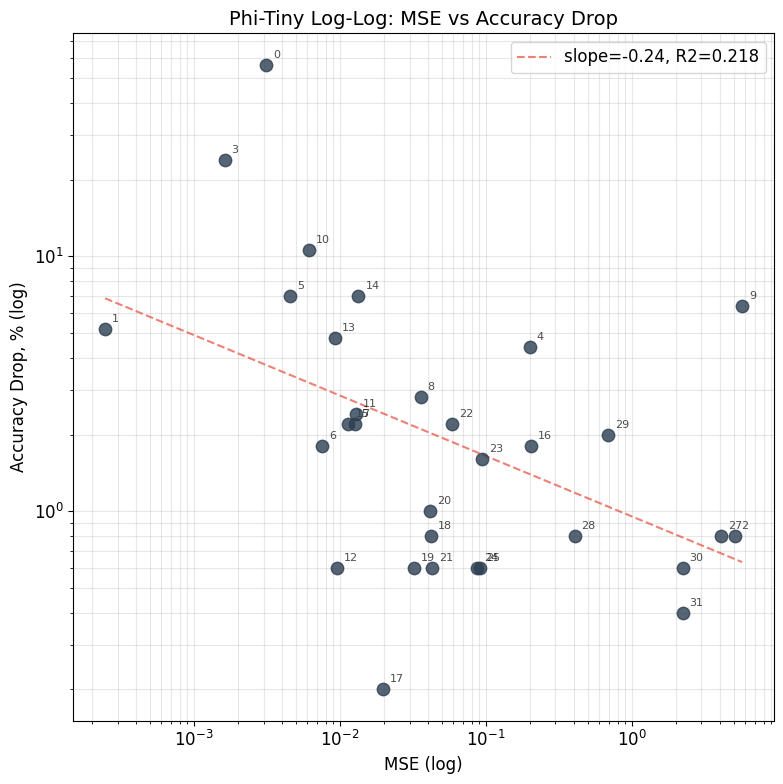

In [20]:
plot_metric_vs_accuracy(df_all, 'MSE')
plot_loglog(df_all, 'MSE')

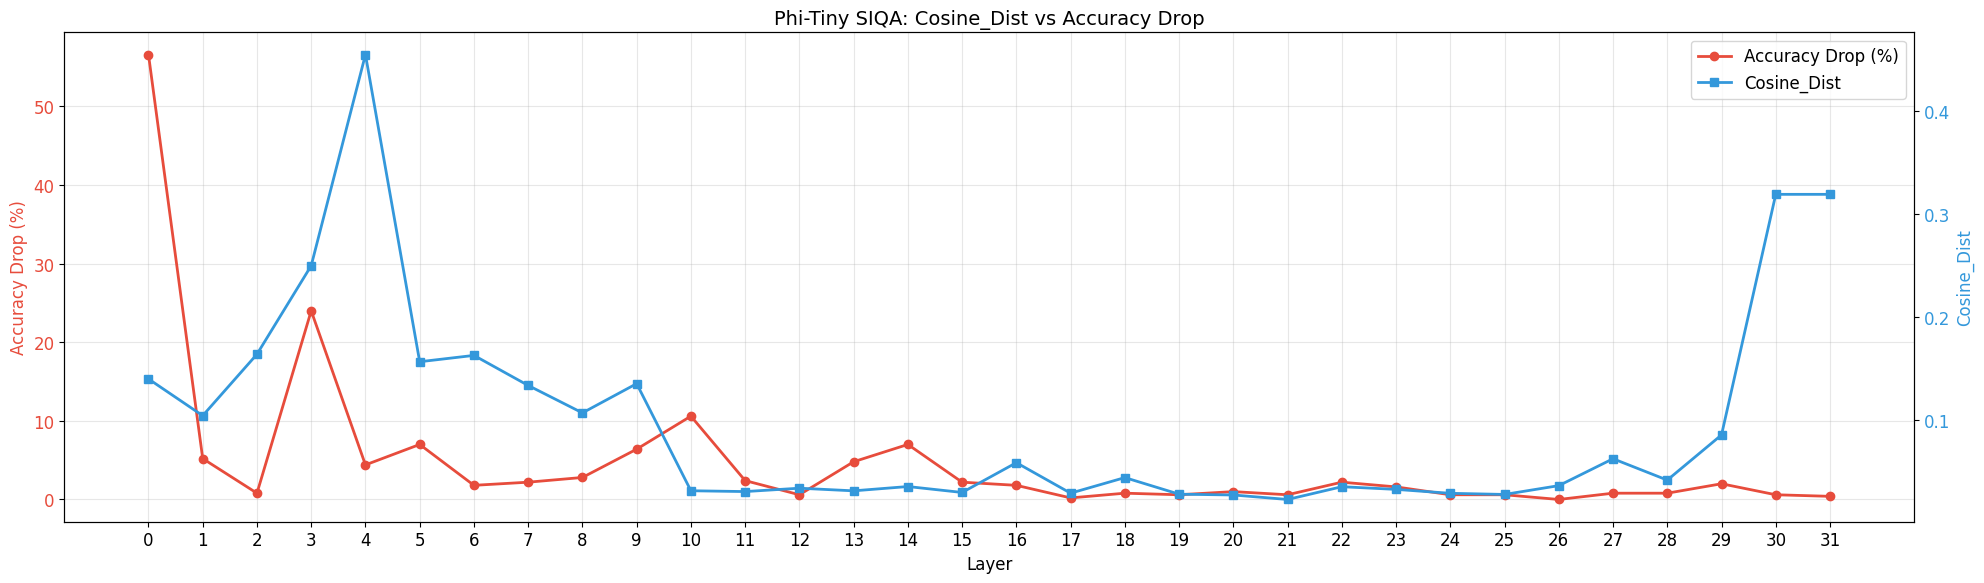

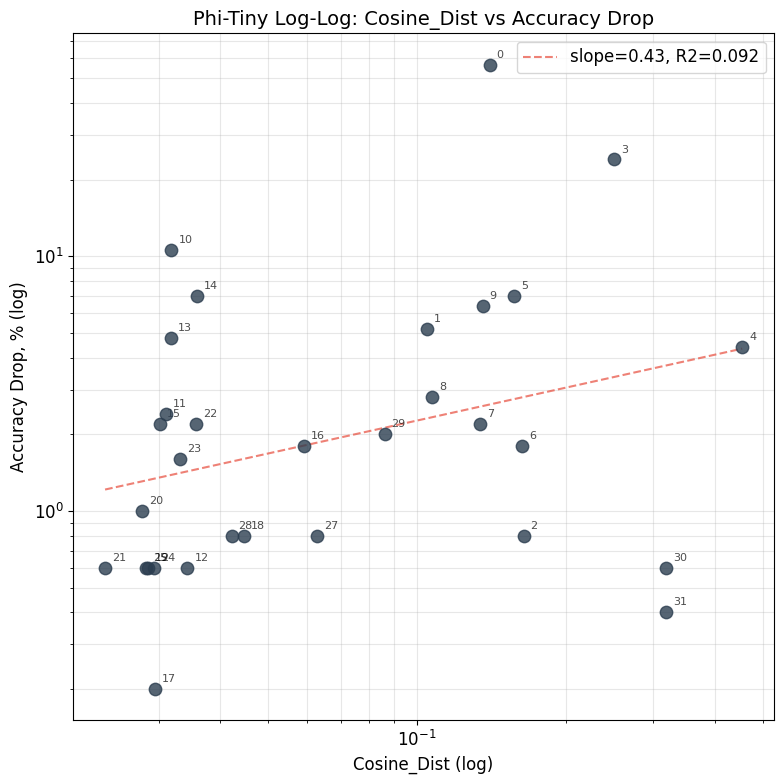

In [21]:
plot_metric_vs_accuracy(df_all, 'Cosine_Dist')
plot_loglog(df_all, 'Cosine_Dist')

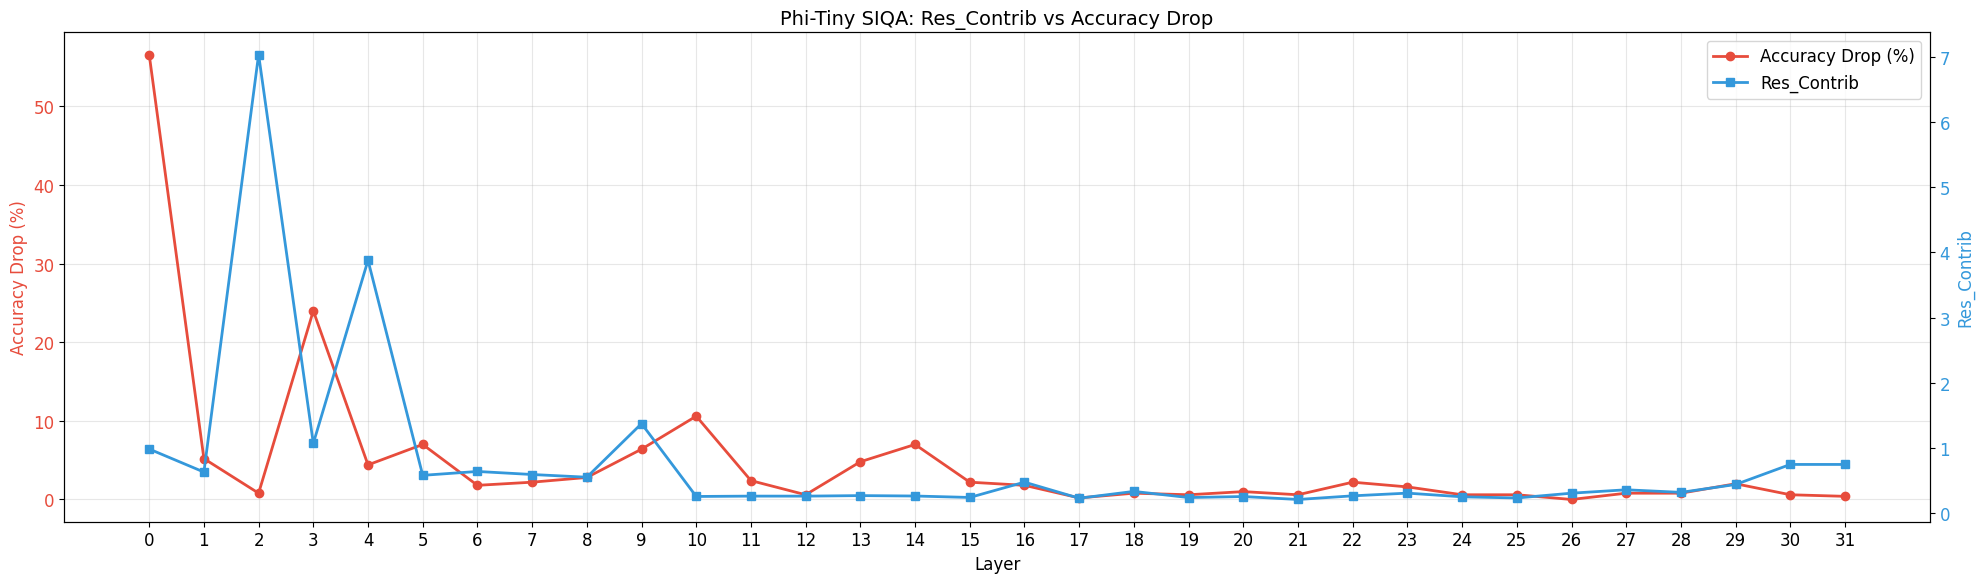

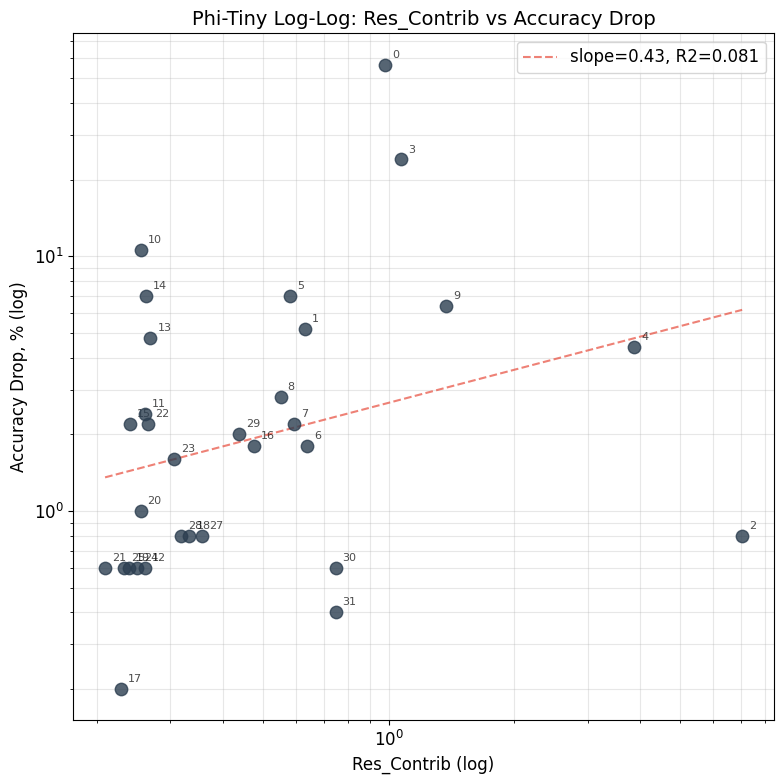

In [22]:
plot_metric_vs_accuracy(df_all, 'Res_Contrib')
plot_loglog(df_all, 'Res_Contrib')

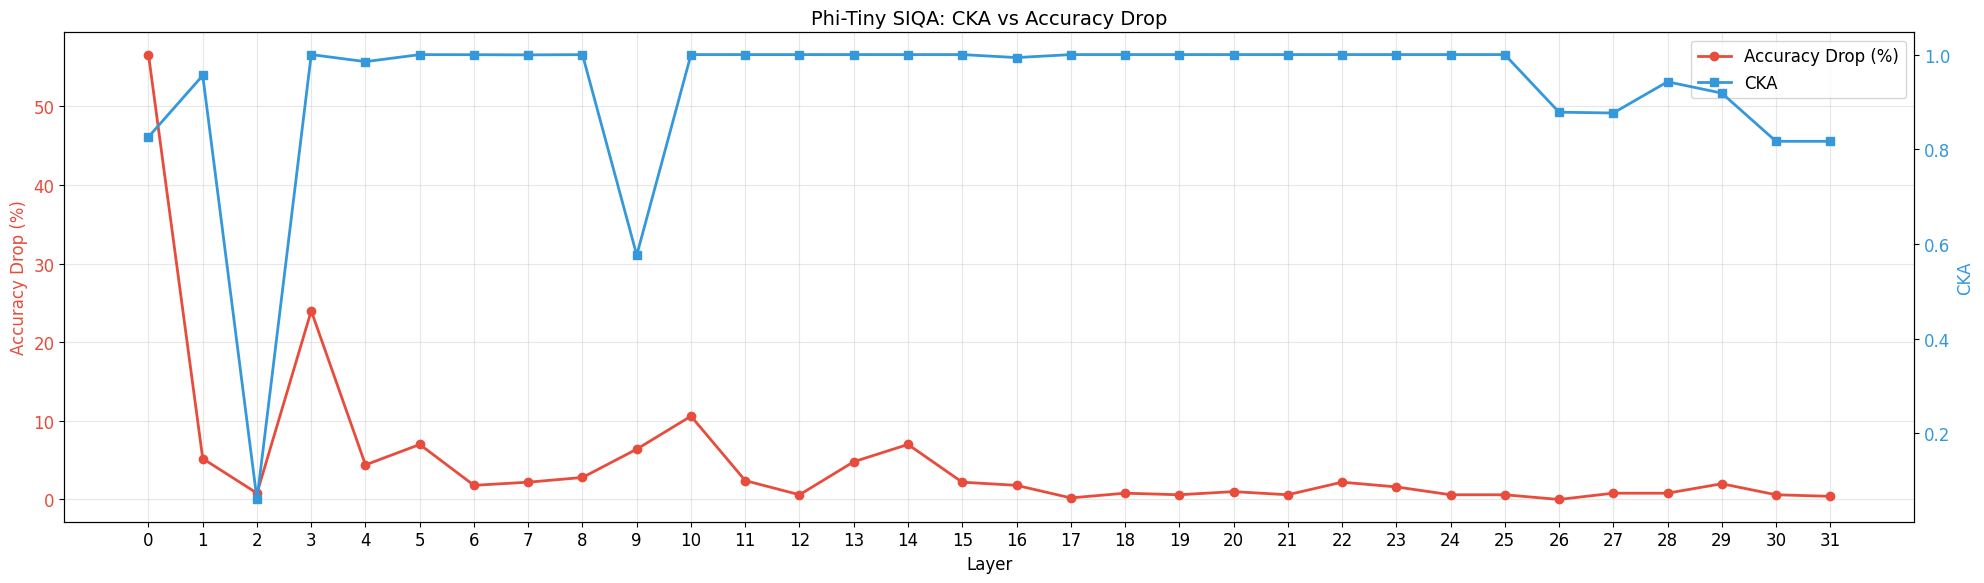

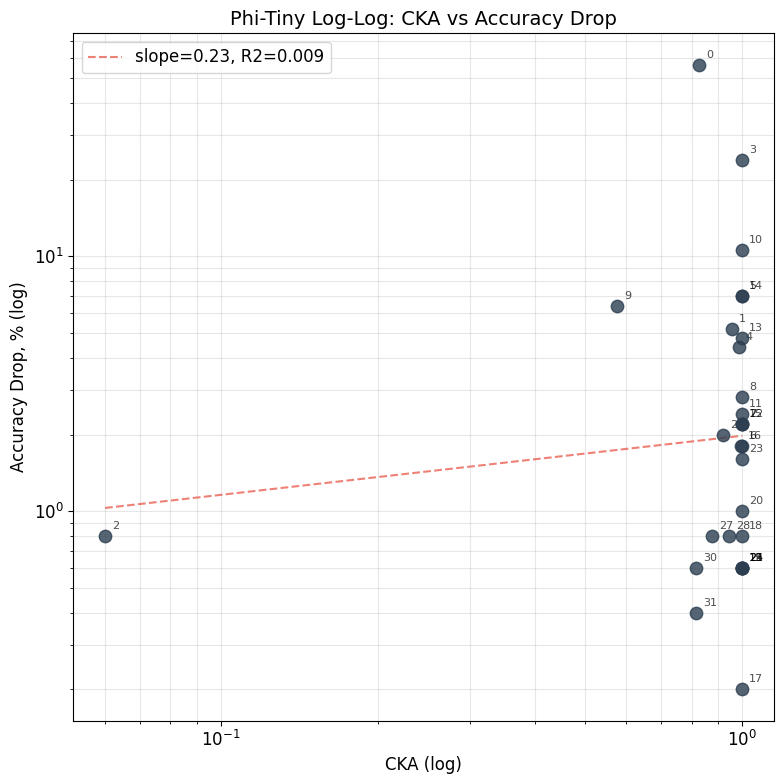

In [23]:
plot_metric_vs_accuracy(df_all, 'CKA')
plot_loglog(df_all, 'CKA')

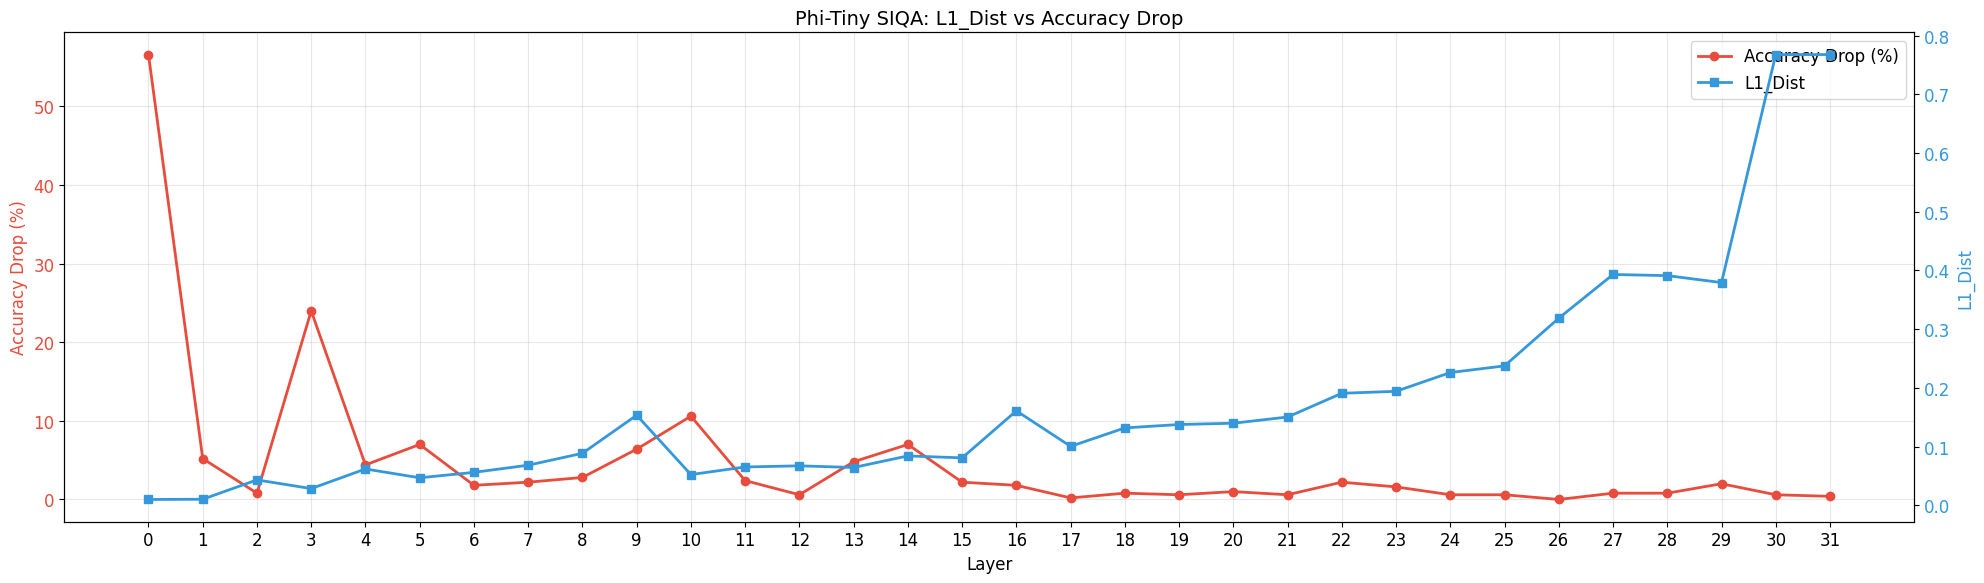

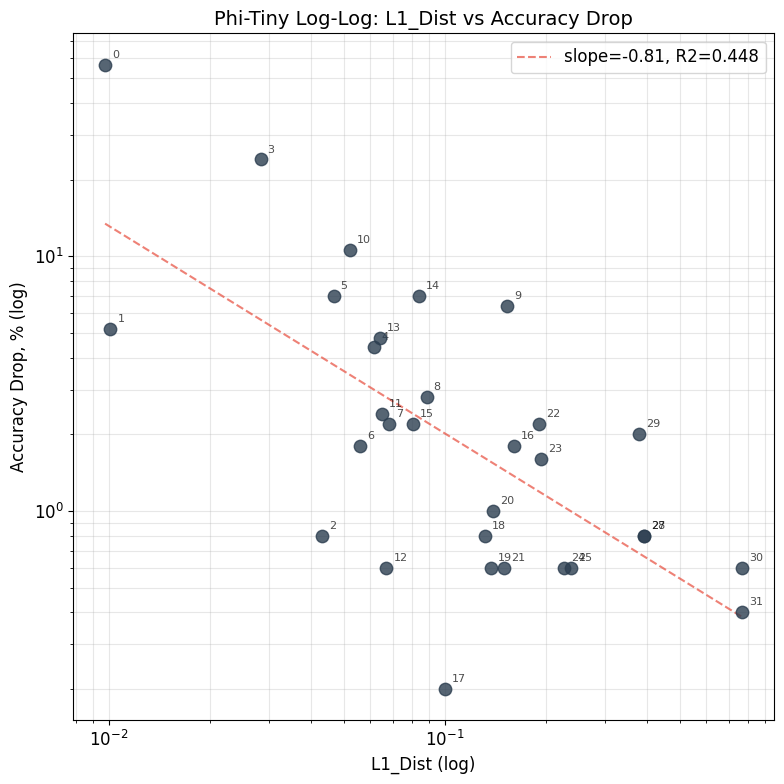

In [24]:
plot_metric_vs_accuracy(df_all, 'L1_Dist')
plot_loglog(df_all, 'L1_Dist')

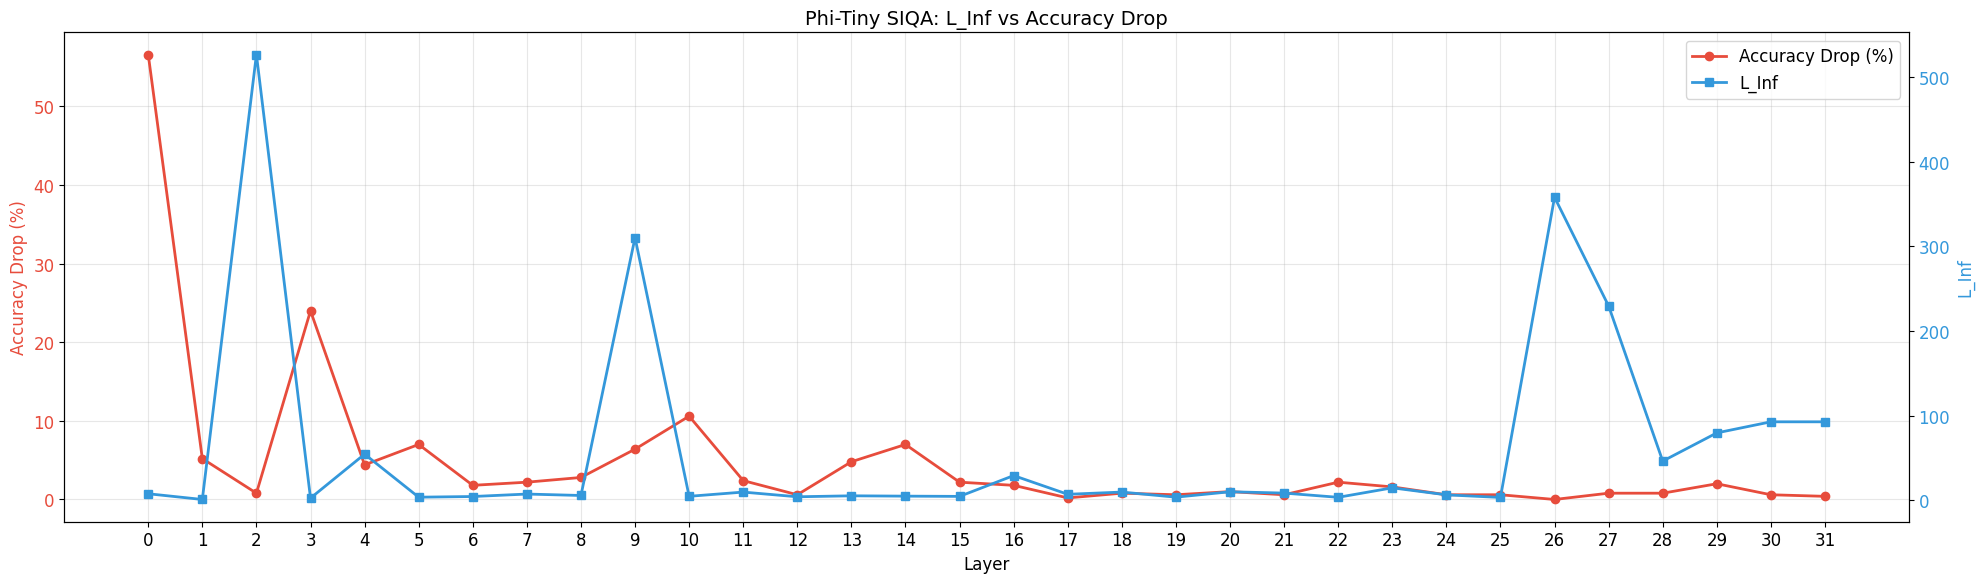

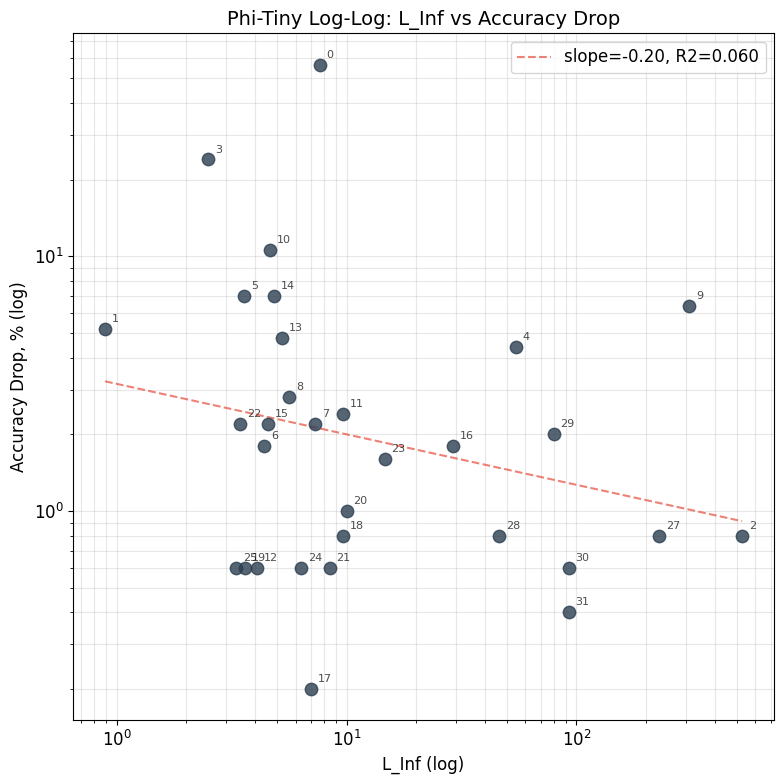

In [25]:
plot_metric_vs_accuracy(df_all, 'L_Inf')
plot_loglog(df_all, 'L_Inf')

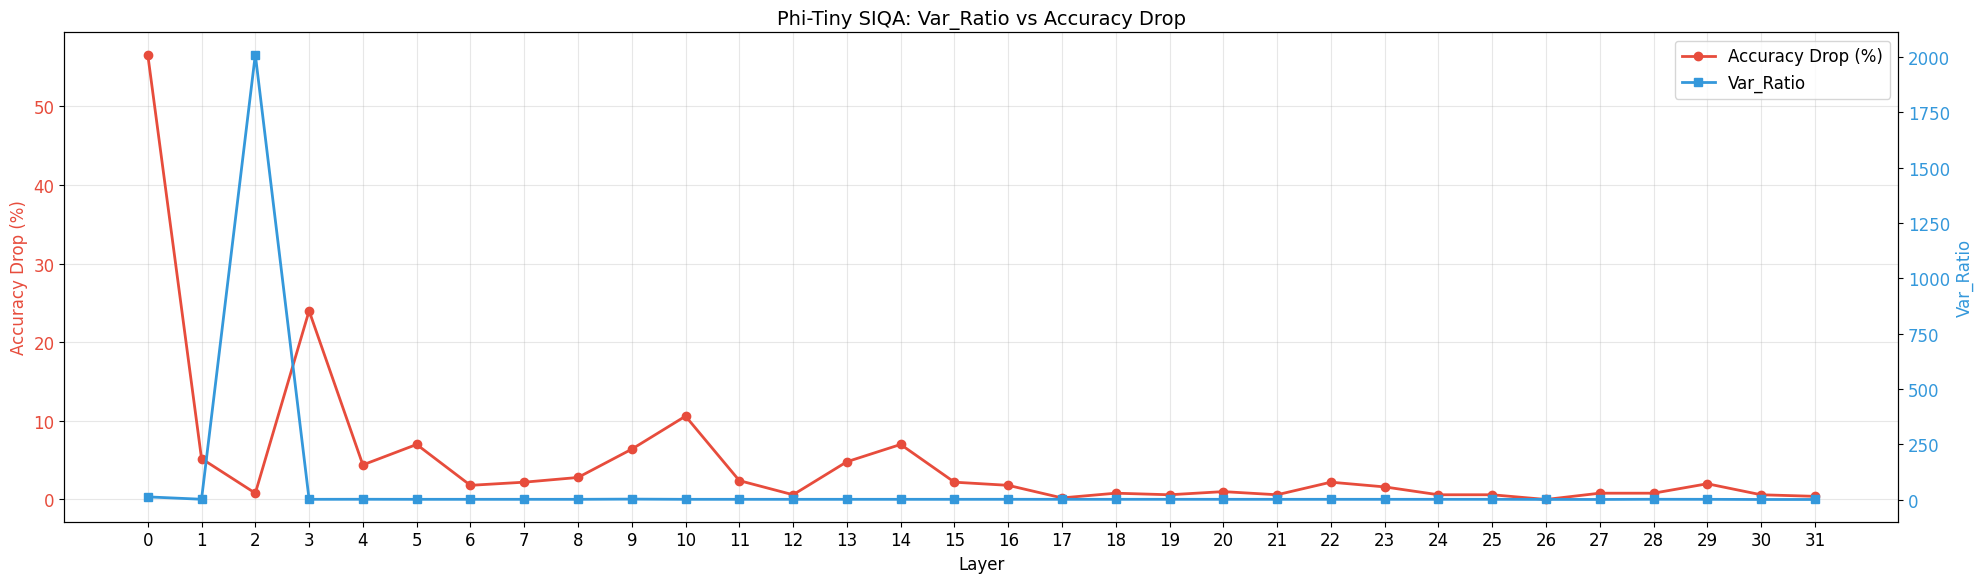

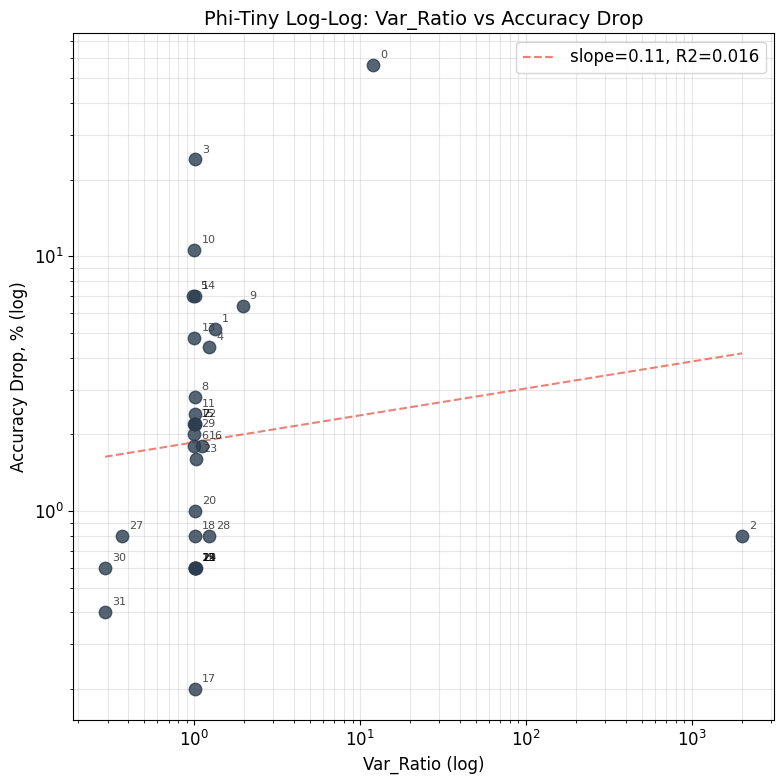

In [26]:
plot_metric_vs_accuracy(df_all, 'Var_Ratio')
plot_loglog(df_all, 'Var_Ratio')

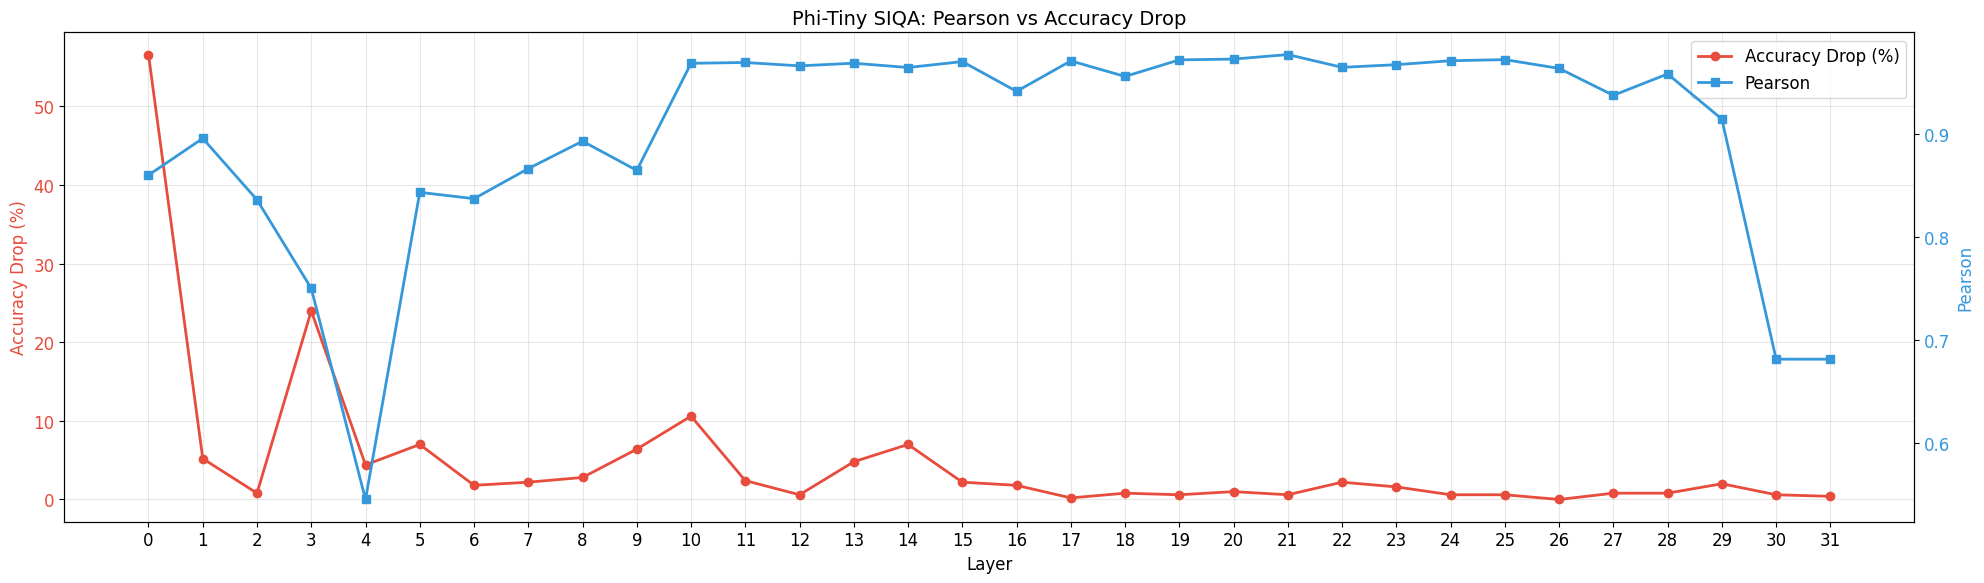

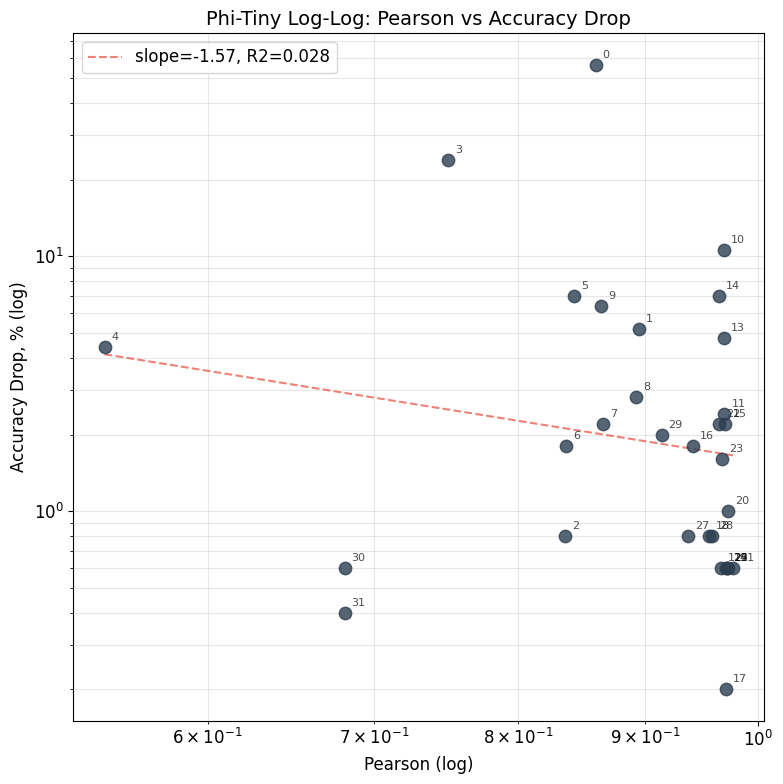

In [27]:
plot_metric_vs_accuracy(df_all, 'Pearson')
plot_loglog(df_all, 'Pearson')

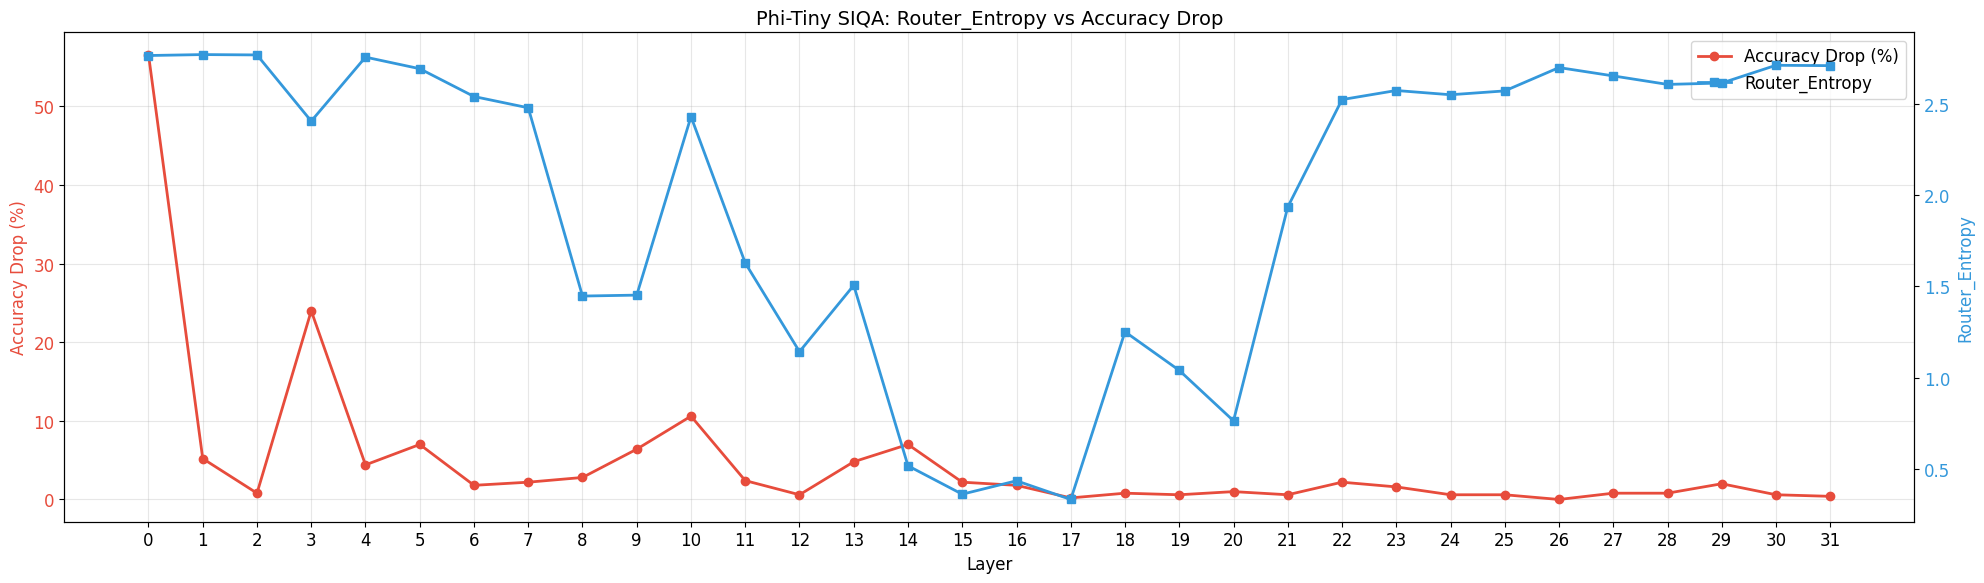

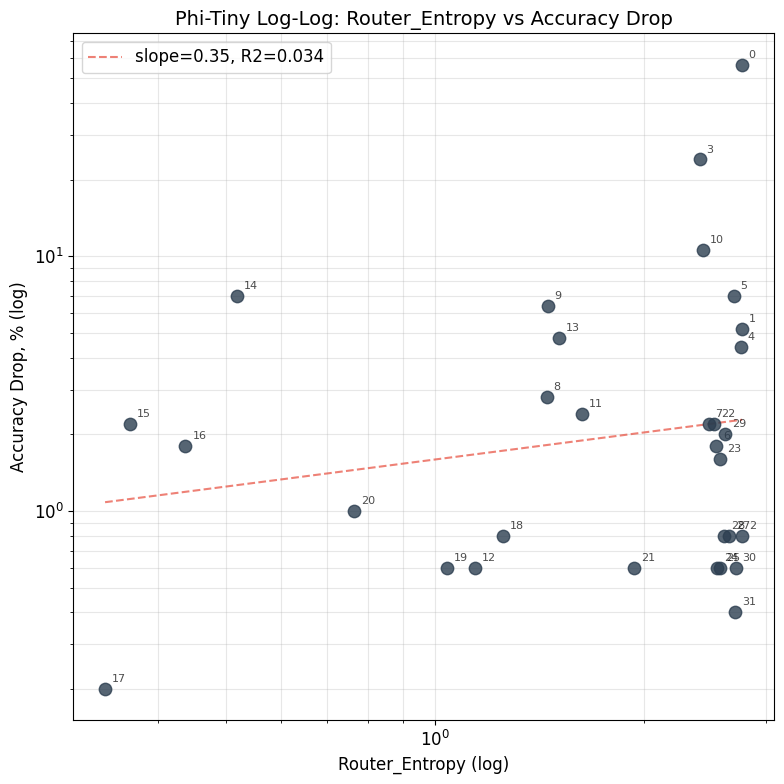

In [28]:
plot_metric_vs_accuracy(df_all, 'Router_Entropy')
plot_loglog(df_all, 'Router_Entropy')

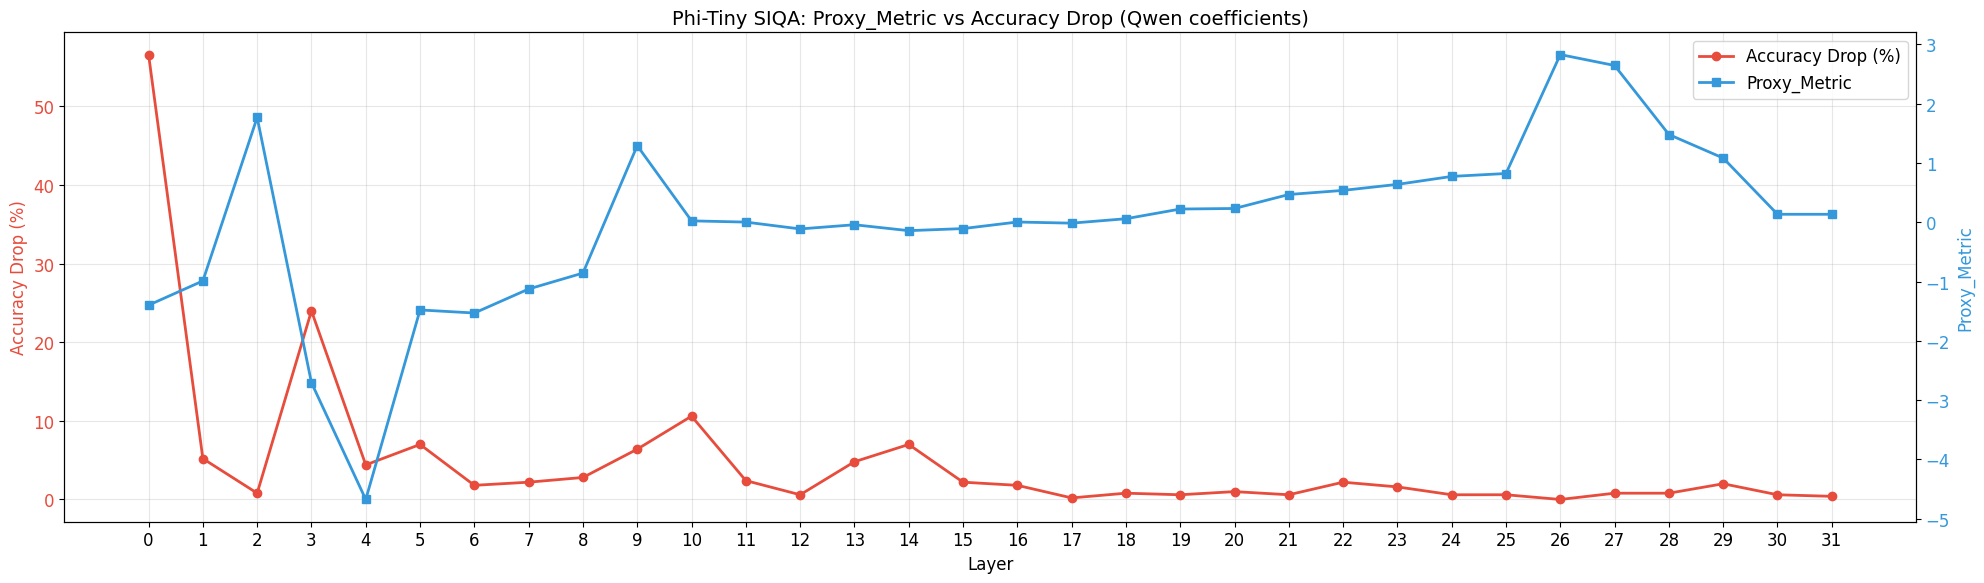

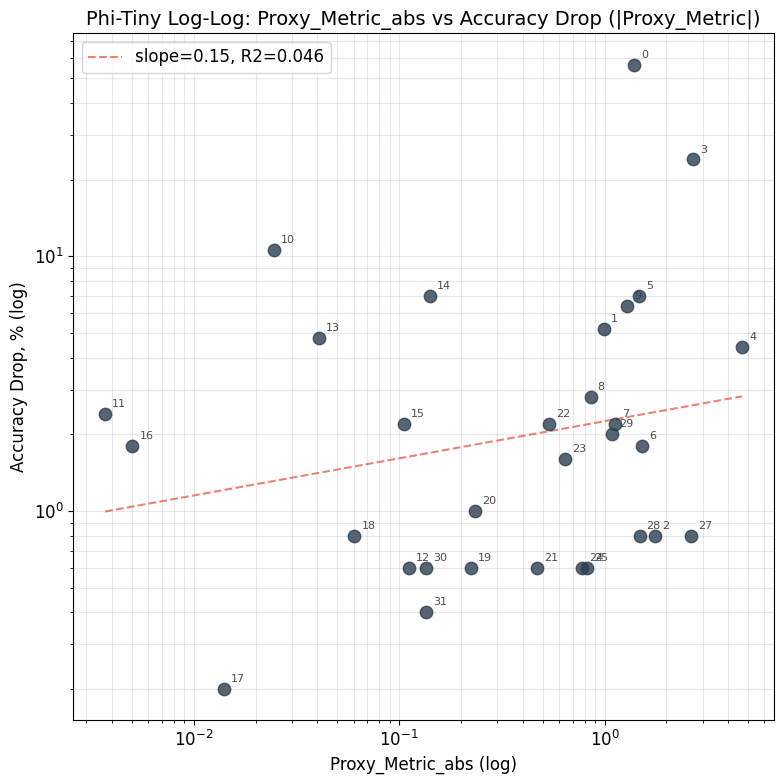

In [29]:
plot_metric_vs_accuracy(df_all, 'Proxy_Metric', ' (Qwen coefficients)')
df_proxy_log = df_all.copy()
df_proxy_log['Proxy_Metric_abs'] = df_proxy_log['Proxy_Metric'].abs()
plot_loglog(df_proxy_log, 'Proxy_Metric_abs', ' (|Proxy_Metric|)')

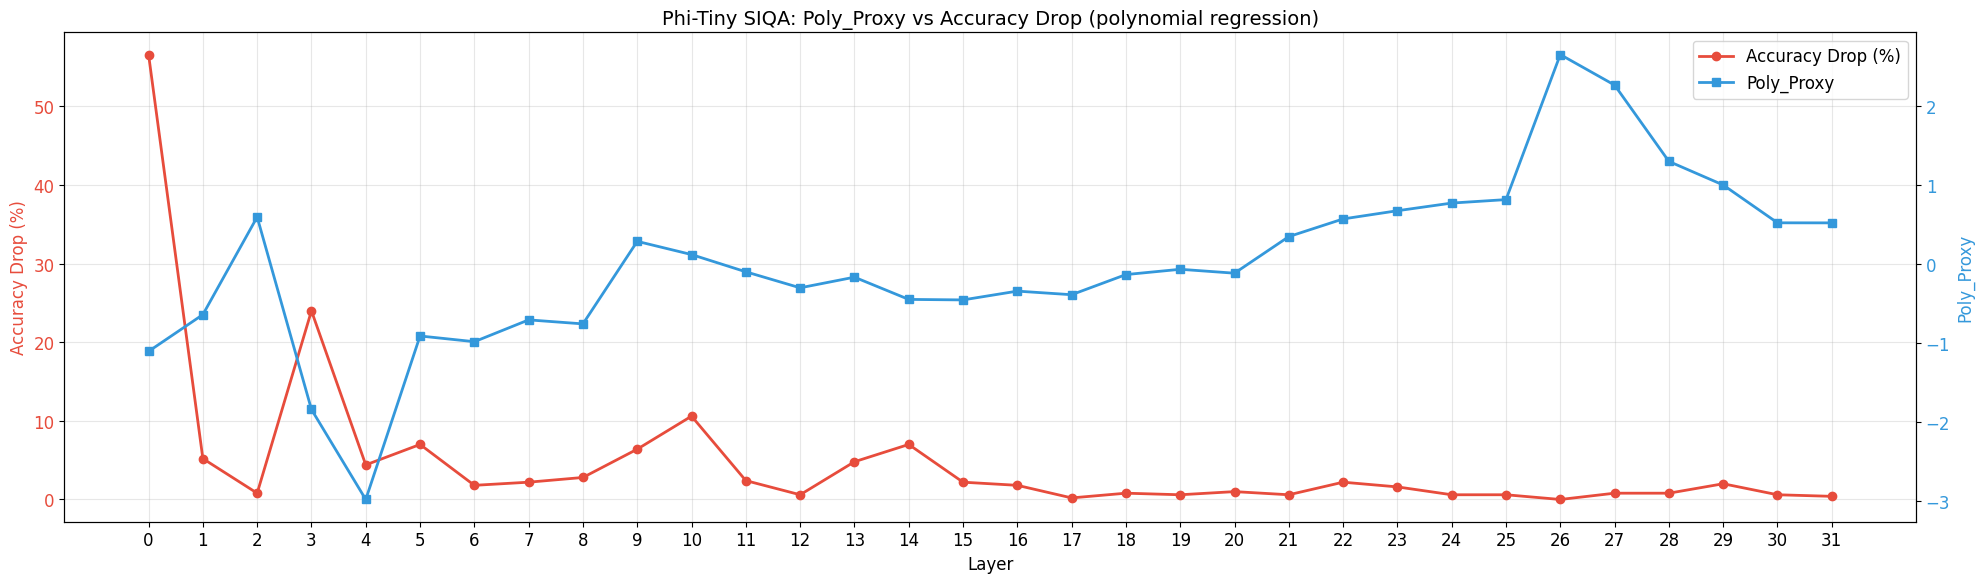

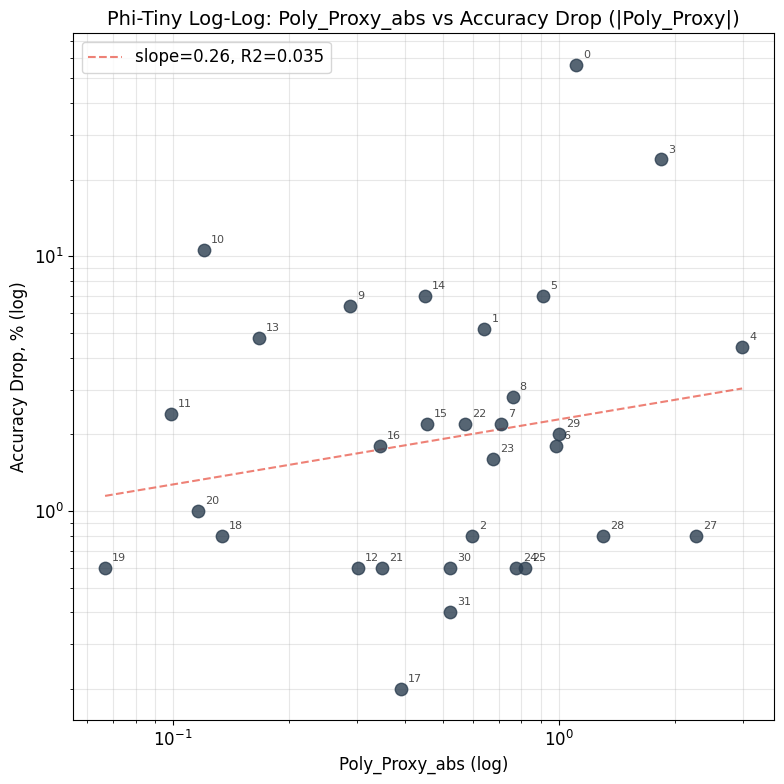

In [30]:
plot_metric_vs_accuracy(df_all, 'Poly_Proxy', ' (polynomial regression)')
df_poly_log = df_all.copy()
df_poly_log['Poly_Proxy_abs'] = df_poly_log['Poly_Proxy'].abs()
plot_loglog(df_poly_log, 'Poly_Proxy_abs', ' (|Poly_Proxy|)')

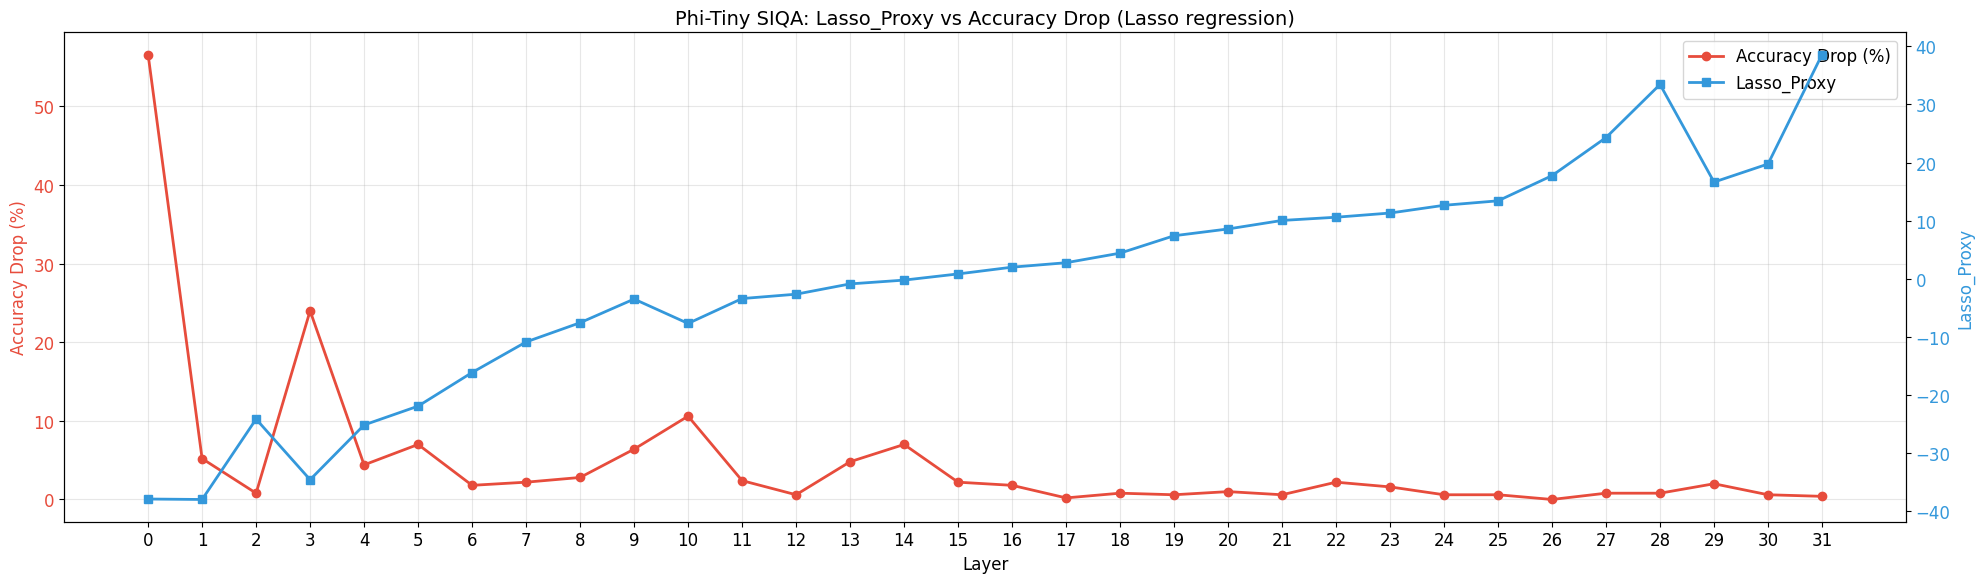

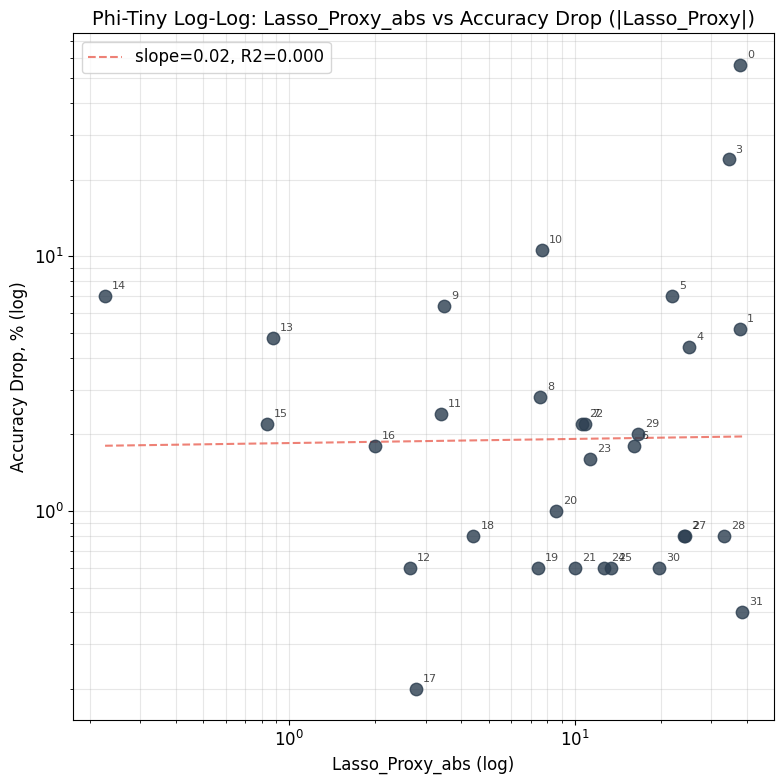

In [31]:
plot_metric_vs_accuracy(df_all, 'Lasso_Proxy', ' (Lasso regression)')
df_lasso_log = df_all.copy()
df_lasso_log['Lasso_Proxy_abs'] = df_lasso_log['Lasso_Proxy'].abs()
plot_loglog(df_lasso_log, 'Lasso_Proxy_abs', ' (|Lasso_Proxy|)')

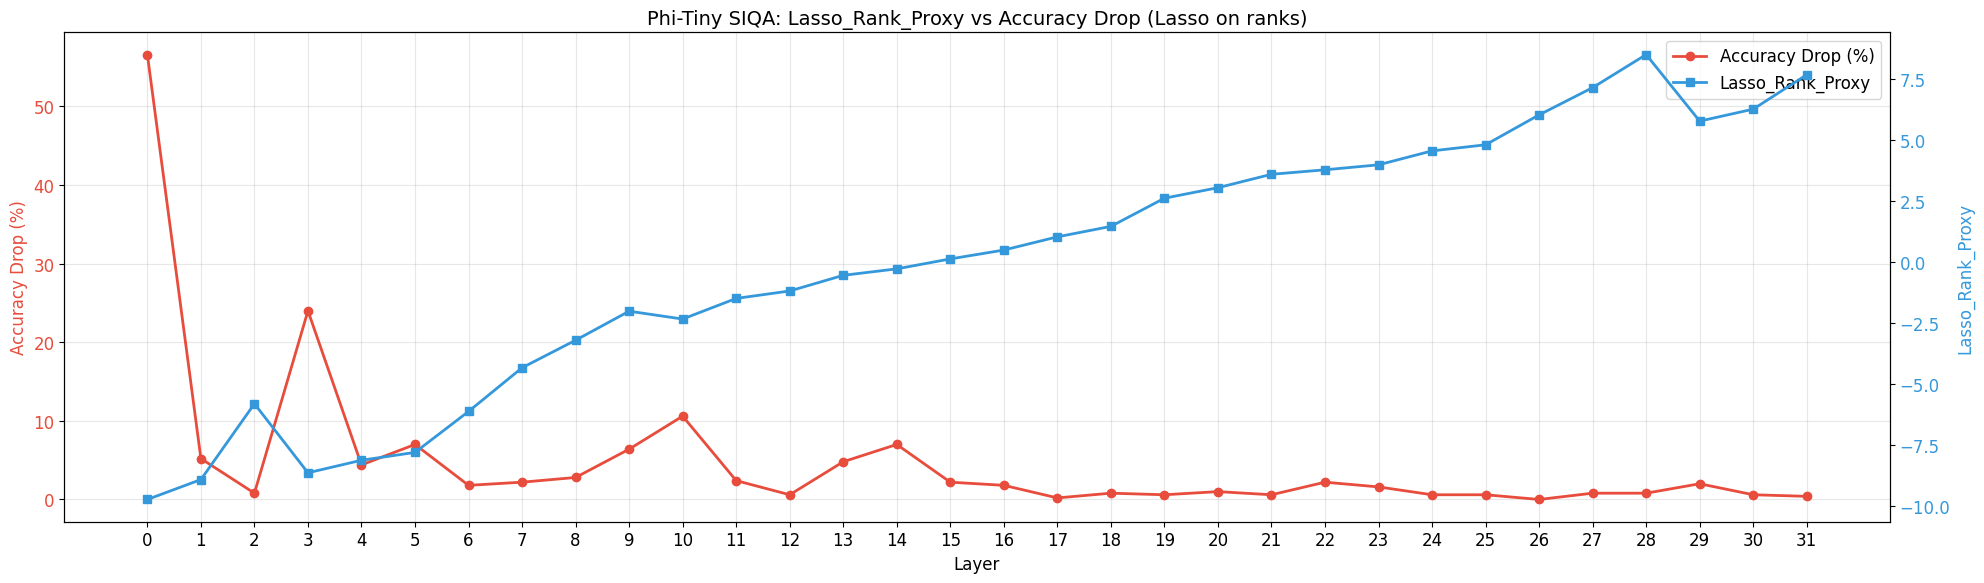

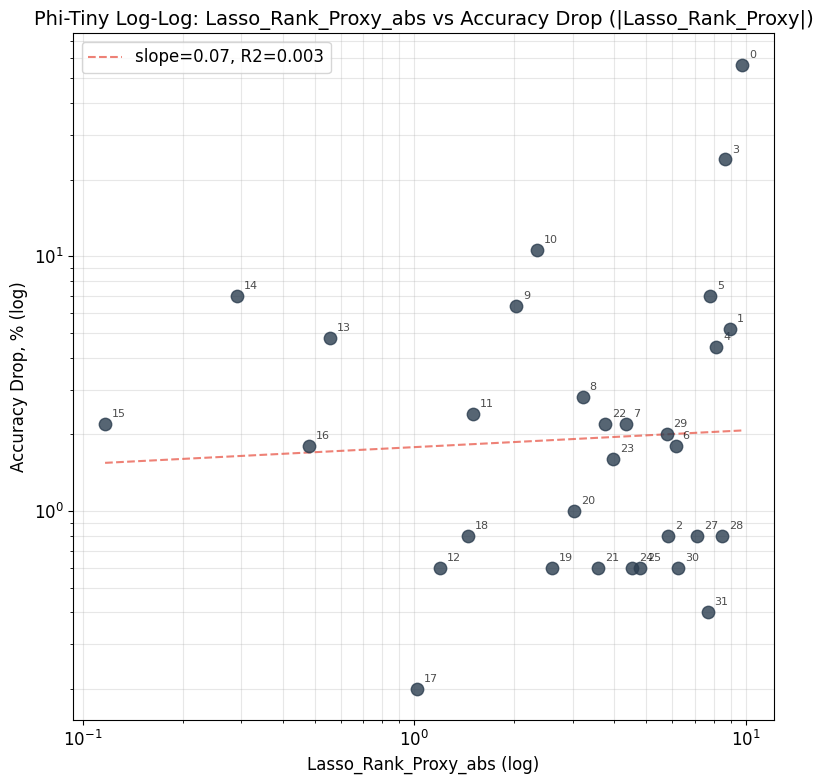

In [32]:
plot_metric_vs_accuracy(df_all, 'Lasso_Rank_Proxy', ' (Lasso on ranks)')
df_lr_log = df_all.copy()
df_lr_log['Lasso_Rank_Proxy_abs'] = df_lr_log['Lasso_Rank_Proxy'].abs()
plot_loglog(df_lr_log, 'Lasso_Rank_Proxy_abs', ' (|Lasso_Rank_Proxy|)')

## 6. Correlation analysis

In [33]:
corr_results = []
for metric_name in all_metrics:
    pr, pp = stats.pearsonr(df_all['Abs_Drop'], df_all[metric_name])
    sr, sp = stats.spearmanr(df_all['Abs_Drop'], df_all[metric_name])
    corr_results.append({'Metric': metric_name, 'Pearson_r': round(pr,4), 'Pearson_p': round(pp,4), 'Spearman_r': round(sr,4), 'Spearman_p': round(sp,4)})
df_corr = pd.DataFrame(corr_results).sort_values('Pearson_r', key=abs, ascending=False)
df_corr

,Metric,Pearson_r,Pearson_p,Spearman_r,Spearman_p
11,Lasso_Proxy,-0.5562,0.0009,-0.7117,0.0000
12,Lasso_Rank_Proxy,-0.5269,0.0019,-0.7163,0.0000
10,Poly_Proxy,-0.3697,0.0373,-0.5878,0.0004
9,Proxy_Metric,-0.3628,0.0413,-0.5572,0.0009
4,L1_Dist,-0.2943,0.1020,-0.6511,0.0001
8,Router_Entropy,0.1859,0.3082,0.0144,0.9378
7,Pearson,-0.1741,0.3407,-0.3134,0.0807
1,Cosine_Dist,0.1738,0.3414,0.3134,0.0807
5,L_Inf,-0.1357,0.4591,-0.3211,0.0732
0,MSE,-0.1283,0.4840,-0.5303,0.0018


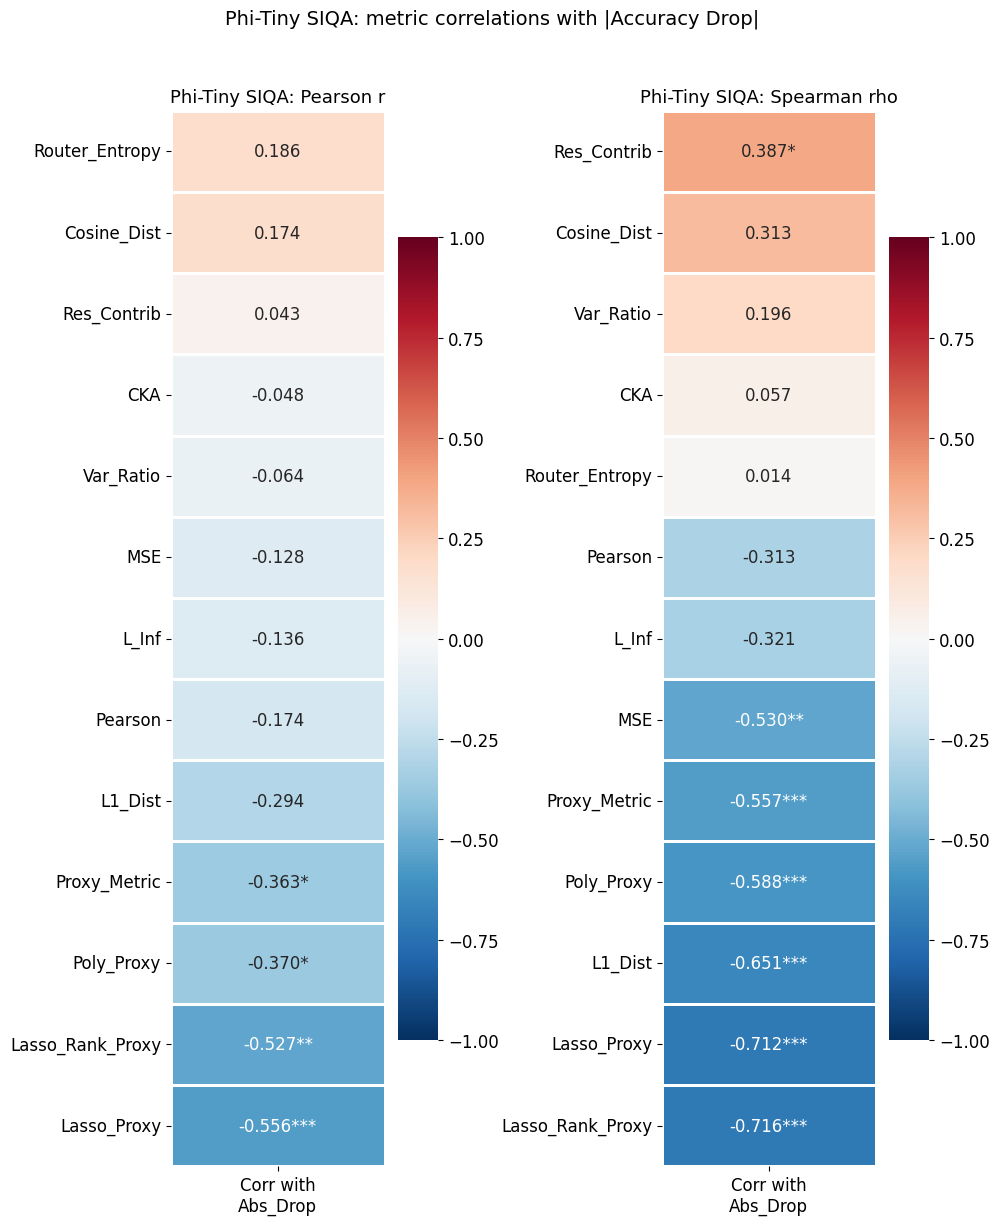

In [34]:
# Heatmap correlations (single column, sorted)
fig, axes = plt.subplots(1, 2, figsize=(10, 12))
for idx, (col, title) in enumerate([('Pearson_r', 'Pearson r'), ('Spearman_r', 'Spearman rho')]):
    df_sorted = df_corr.sort_values(col, ascending=False)
    data = df_sorted[[col]].rename(columns={col: 'Corr with\nAbs_Drop'})
    data.index = df_sorted['Metric']
    p_col = col.replace('_r', '_p')
    annot_vals = []
    for _, row in df_sorted.iterrows():
        v = row[col]; p = row[p_col]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        annot_vals.append(f'{v:.3f}{sig}')
    annot_arr = np.array(annot_vals).reshape(-1, 1)
    sns.heatmap(data, annot=annot_arr, fmt='', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=axes[idx], linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'Phi-Tiny SIQA: {title}', fontsize=13); axes[idx].set_ylabel('')
plt.suptitle('Phi-Tiny SIQA: metric correlations with |Accuracy Drop|', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

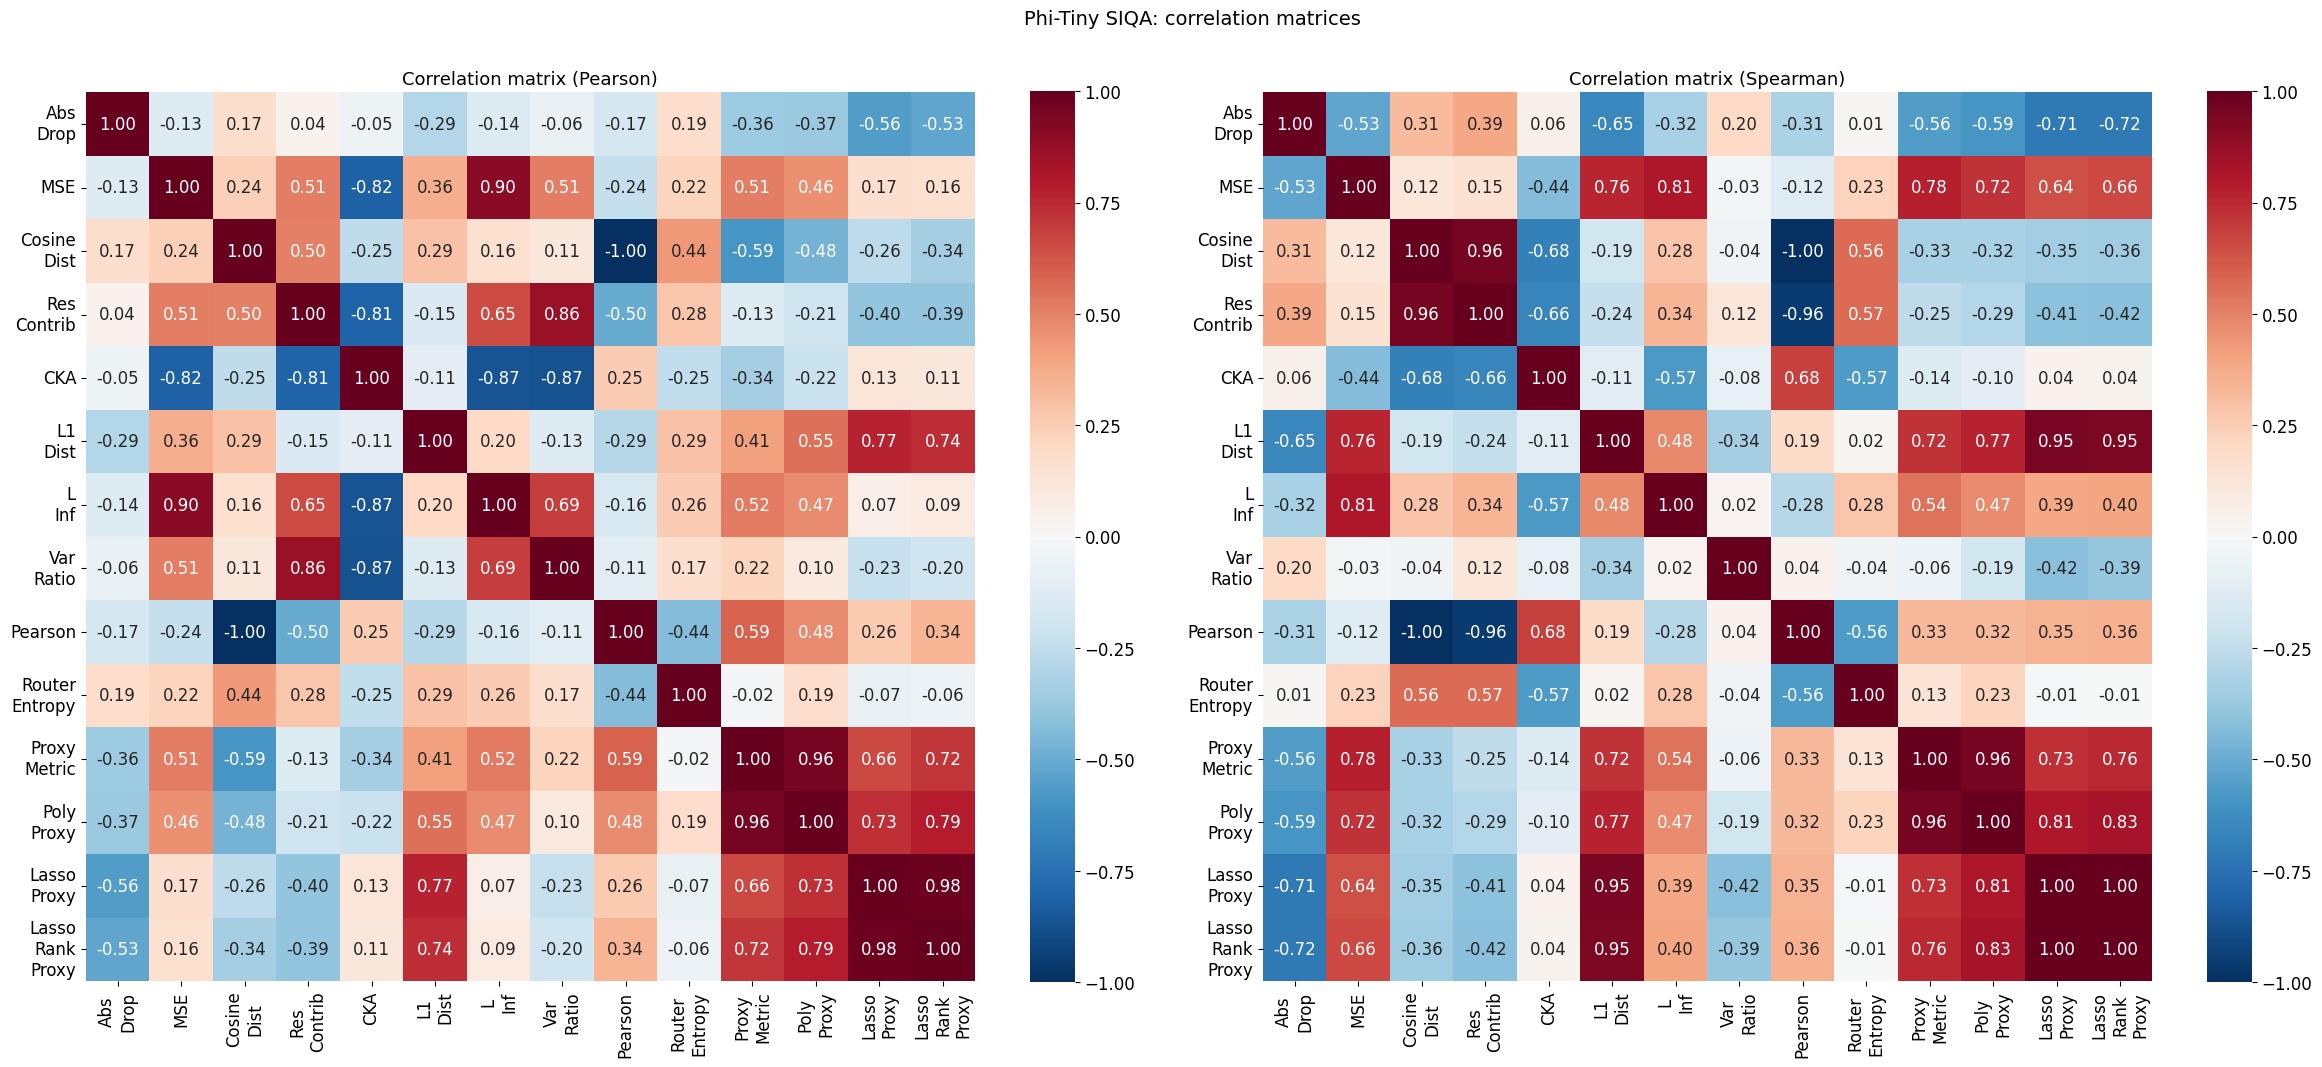

In [35]:
# Full correlation matrices
cols_for_corr = ['Abs_Drop'] + all_metrics
df_cm = df_all[cols_for_corr]
fig, axes = plt.subplots(1, 2, figsize=(24, 10))
for idx, method in enumerate(['pearson', 'spearman']):
    mat = df_cm.corr(method=method)
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=axes[idx], vmin=-1, vmax=1,
                xticklabels=[c.replace('_','\n') for c in cols_for_corr], yticklabels=[c.replace('_','\n') for c in cols_for_corr])
    axes[idx].set_title(f'Correlation matrix ({method.title()})', fontsize=13)
plt.suptitle('Phi-Tiny SIQA: correlation matrices', fontsize=14, y=1.02); plt.tight_layout(); plt.show()

## 7. All metrics on one plot

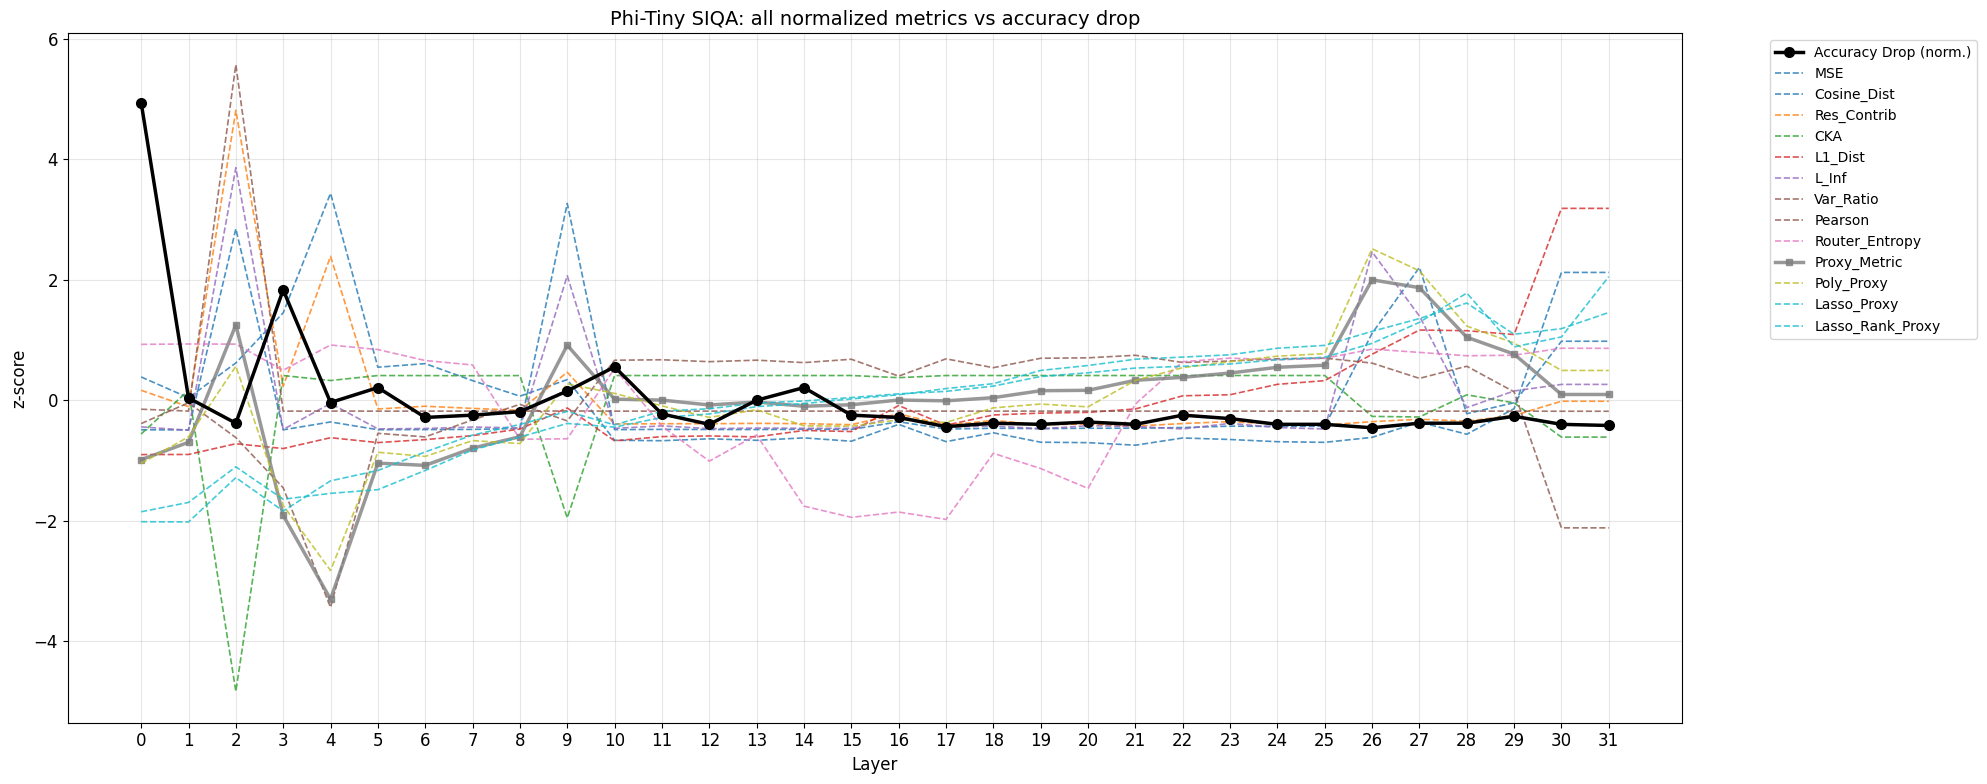

In [36]:
fig, ax = plt.subplots(figsize=(20, 8))
x = np.arange(num_layers)
acc_norm = (df_all['Abs_Drop'] - df_all['Abs_Drop'].mean()) / df_all['Abs_Drop'].std()
ax.plot(x, acc_norm, 'k-o', linewidth=2.5, markersize=7, label='Accuracy Drop (norm.)', zorder=10)
colors = plt.cm.tab10(np.linspace(0, 1, len(all_metrics)))
for i, mn in enumerate(all_metrics):
    vals = np.array(df_all[mn], dtype=float)
    vn = (vals - vals.mean()) / vals.std() if vals.std() > 0 else vals - vals.mean()
    lw = 2.5 if mn == 'Proxy_Metric' else 1.2
    ls = '-' if mn == 'Proxy_Metric' else '--'
    ax.plot(x, vn, color=colors[i], linewidth=lw, linestyle=ls, marker='s' if mn=='Proxy_Metric' else None, markersize=5, label=mn, alpha=0.8)
ax.set_xlabel('Layer'); ax.set_ylabel('z-score'); ax.set_title('Phi-Tiny SIQA: all normalized metrics vs accuracy drop')
ax.set_xticks(x); ax.set_xticklabels([str(i) for i in range(num_layers)])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Heatmaps for all layer pairs

Full 32x32 matrices for layer block analysis.

In [37]:
def plot_metric_heatmap(metric_name, filename, use_log=False):
    df_m = pd.read_csv(os.path.join(metrics_dir, filename), index_col=0)
    labels = [str(i) for i in range(num_layers)]
    data = df_m.values.astype(float)
    if use_log:
        data_plot = data.copy()
        data_plot[data_plot <= 0] = np.nan
        with np.errstate(invalid='ignore'):
            data_plot = np.log10(data_plot)
        title = f'Phi-Tiny SIQA: {metric_name} - Heatmap (log10)'
        fmt = '.1f'
    else:
        data_plot = data
        title = f'Phi-Tiny SIQA: {metric_name} - Heatmap'
        mx = np.nanmax(np.abs(data_plot))
        fmt = '.2f' if mx < 10 else '.1f' if mx < 100 else '.0f'
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(data_plot, annot=True, fmt=fmt, cmap='viridis', xticklabels=labels, yticklabels=labels,
                square=True, ax=ax, linewidths=0.2, linecolor='white', annot_kws={'size': 7})
    ax.set_xlabel('Layer j'); ax.set_ylabel('Layer i'); ax.set_title(title, fontsize=14)
    plt.tight_layout(); plt.show()

print('Heatmap function ready')

Heatmap function ready


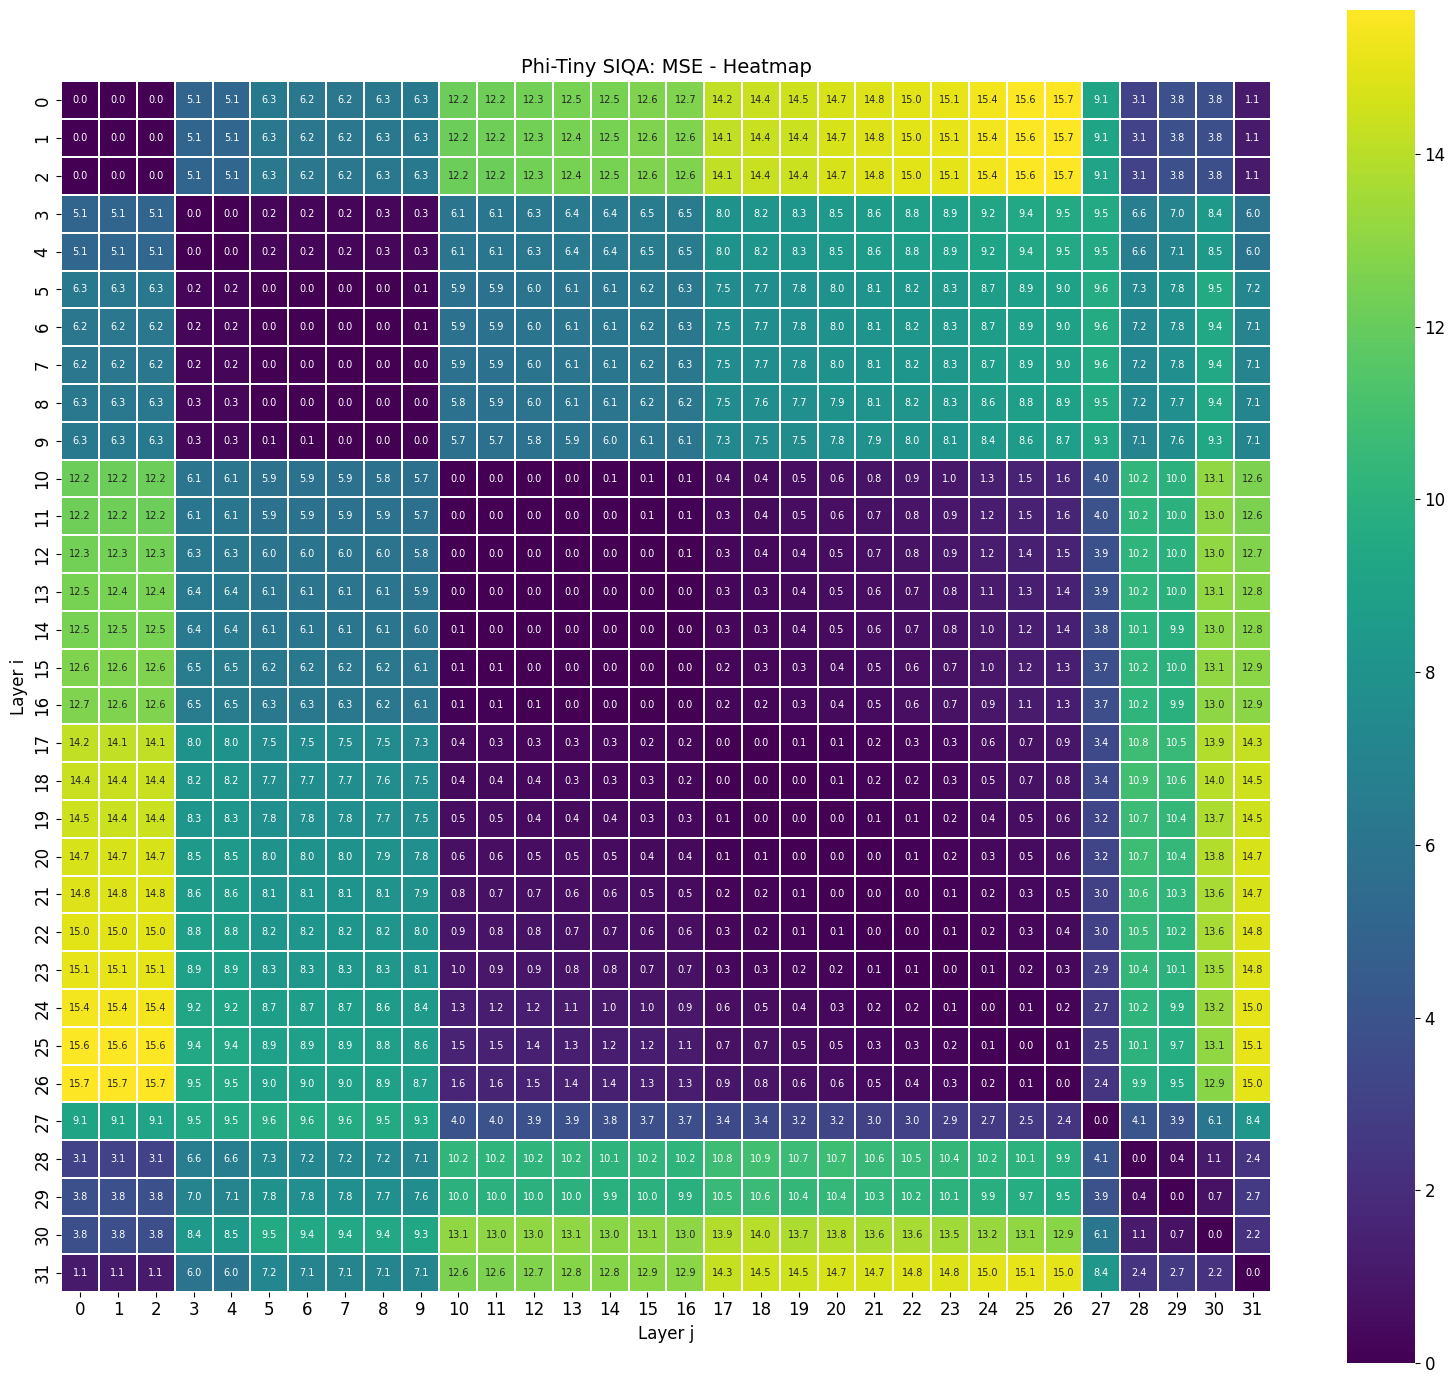

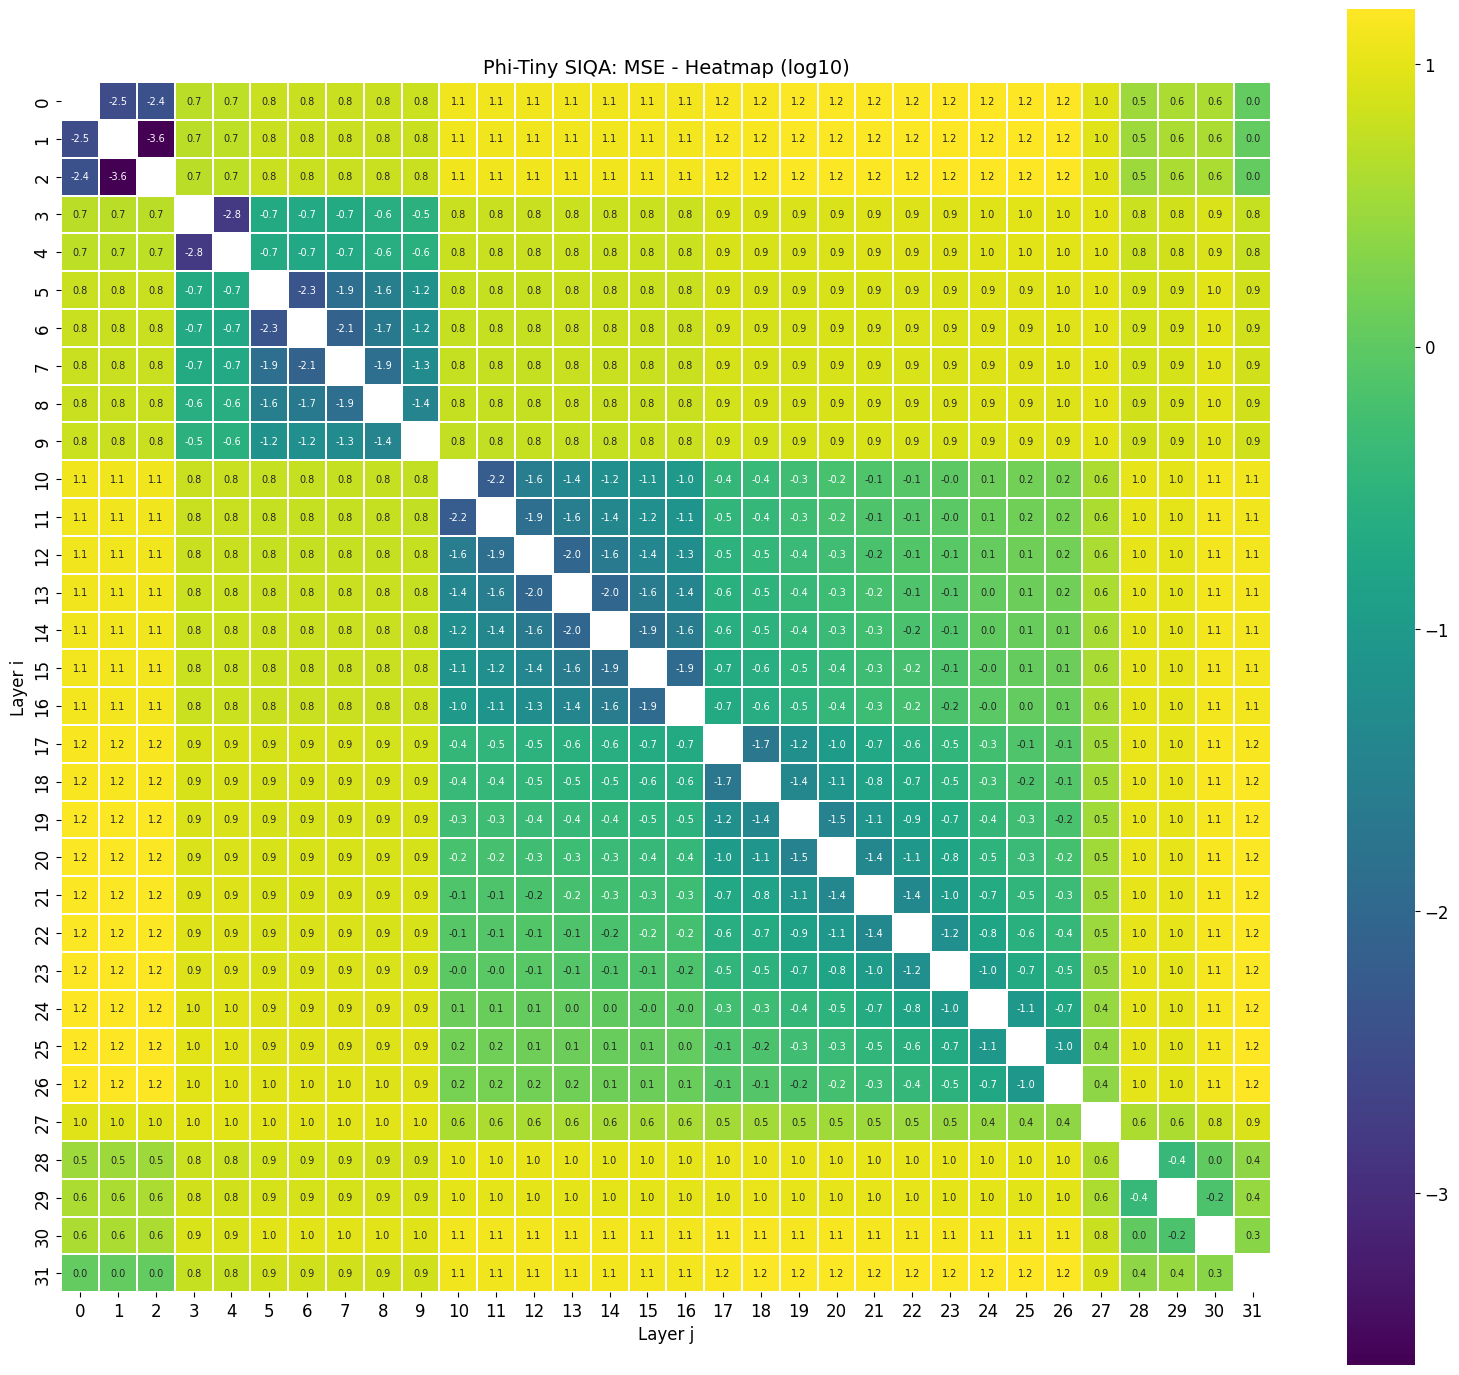

In [38]:
plot_metric_heatmap('MSE', 'metric_01_MSE.csv')
plot_metric_heatmap('MSE', 'metric_01_MSE.csv', use_log=True)

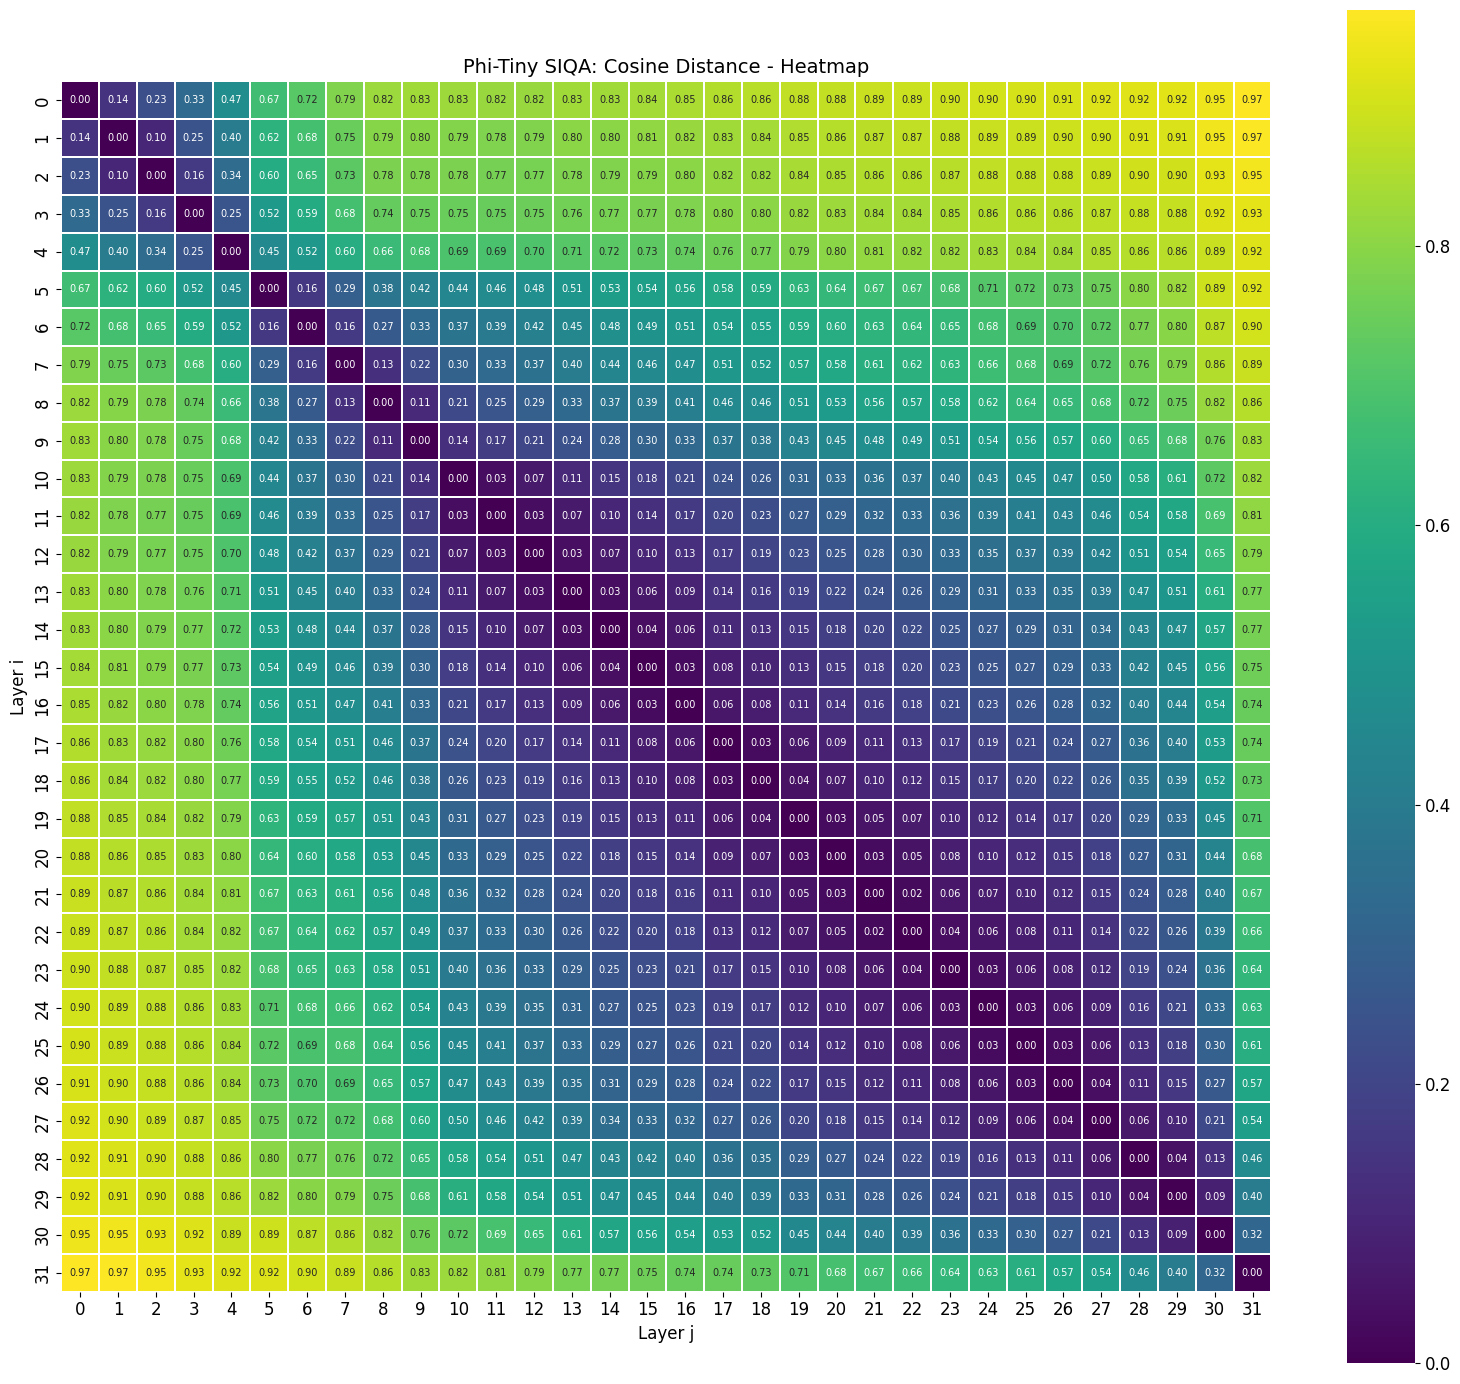

In [39]:
plot_metric_heatmap('Cosine Distance', 'metric_02_Cosine_Distance.csv')

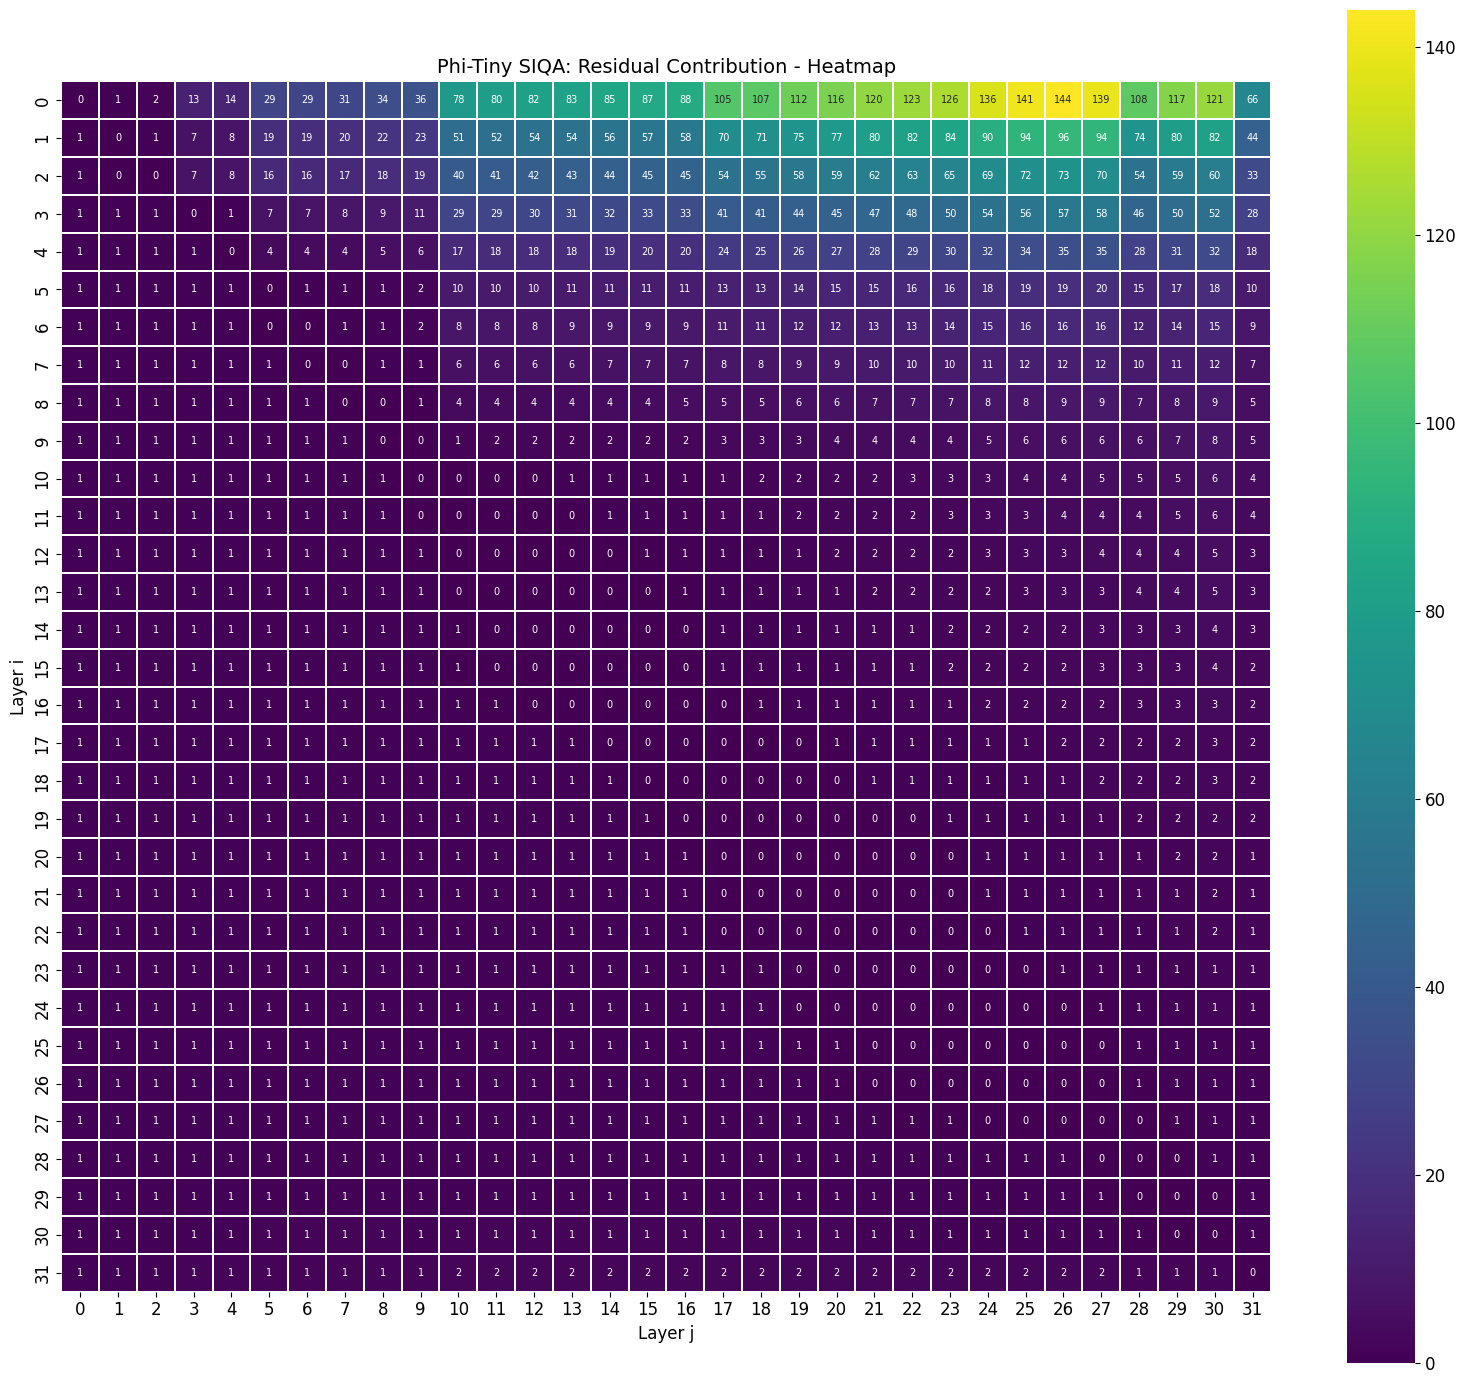

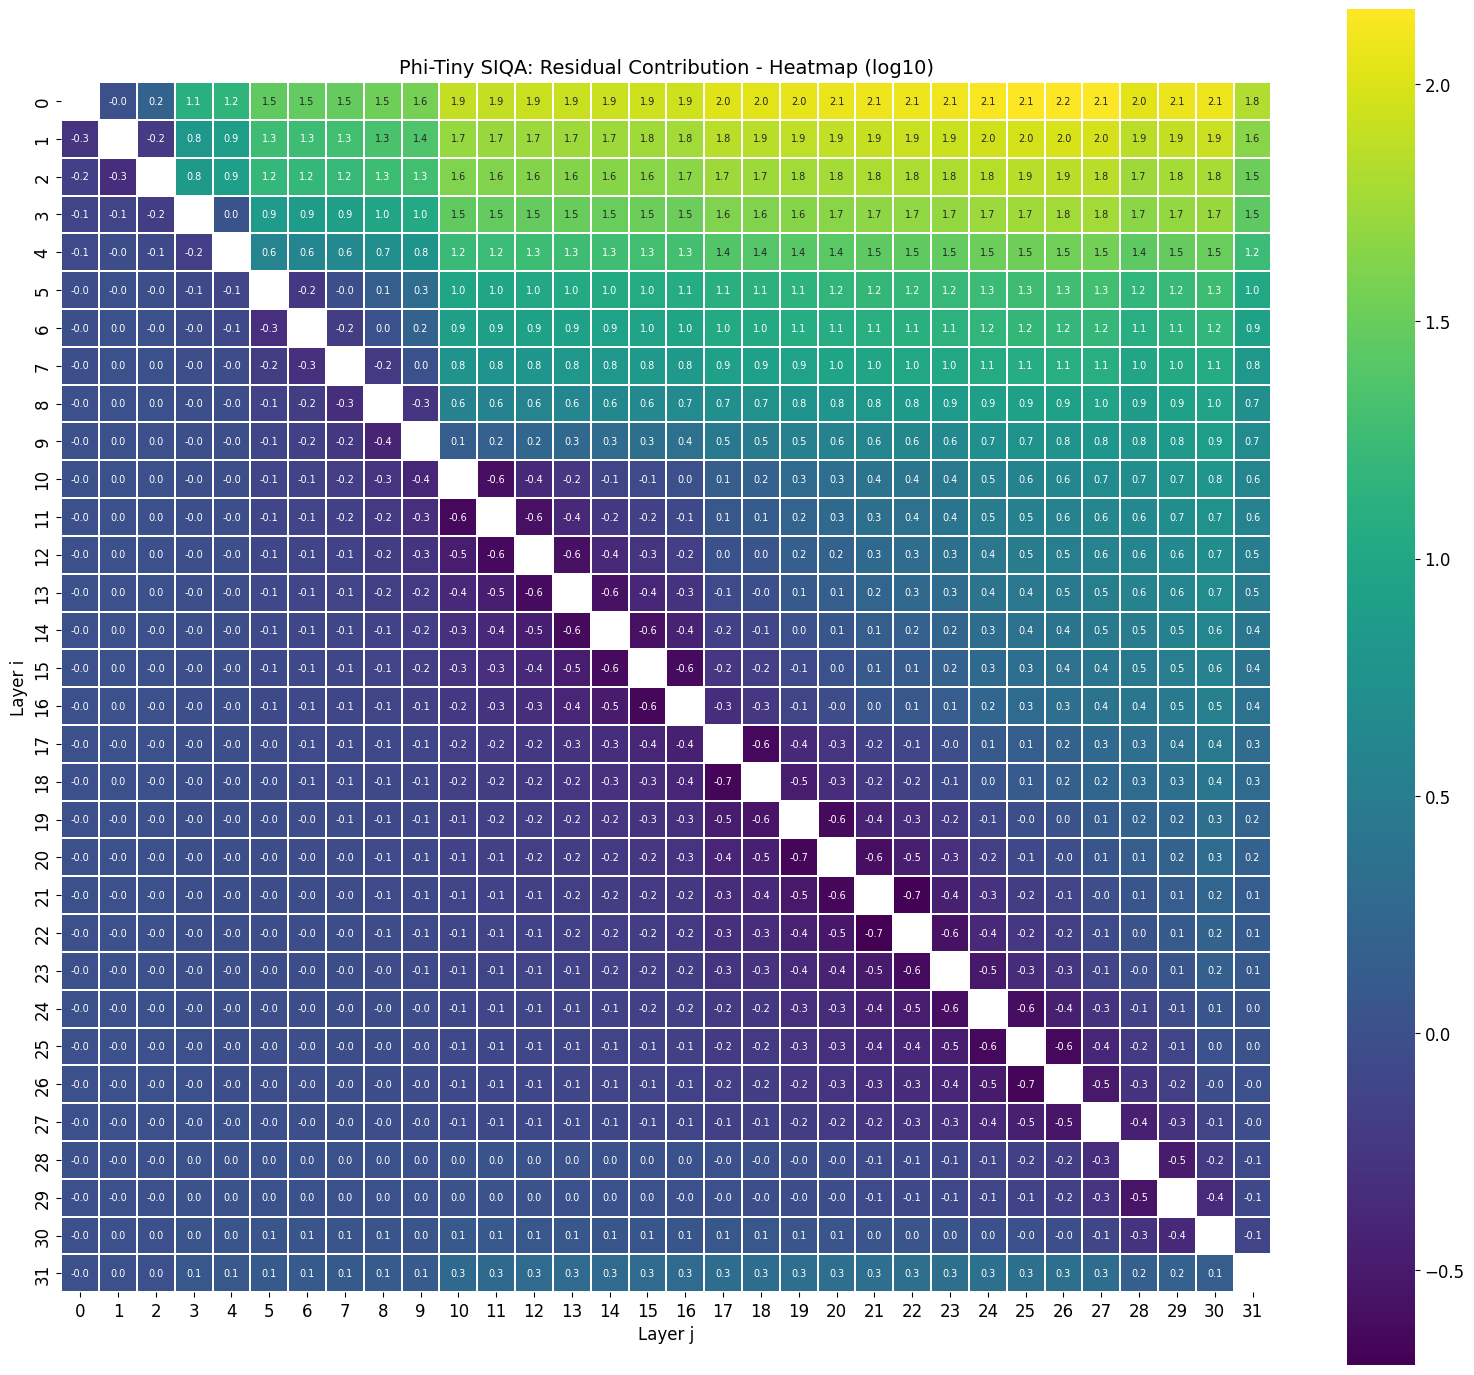

In [40]:
plot_metric_heatmap('Residual Contribution', 'metric_03_Residual_Contribution.csv')
plot_metric_heatmap('Residual Contribution', 'metric_03_Residual_Contribution.csv', use_log=True)

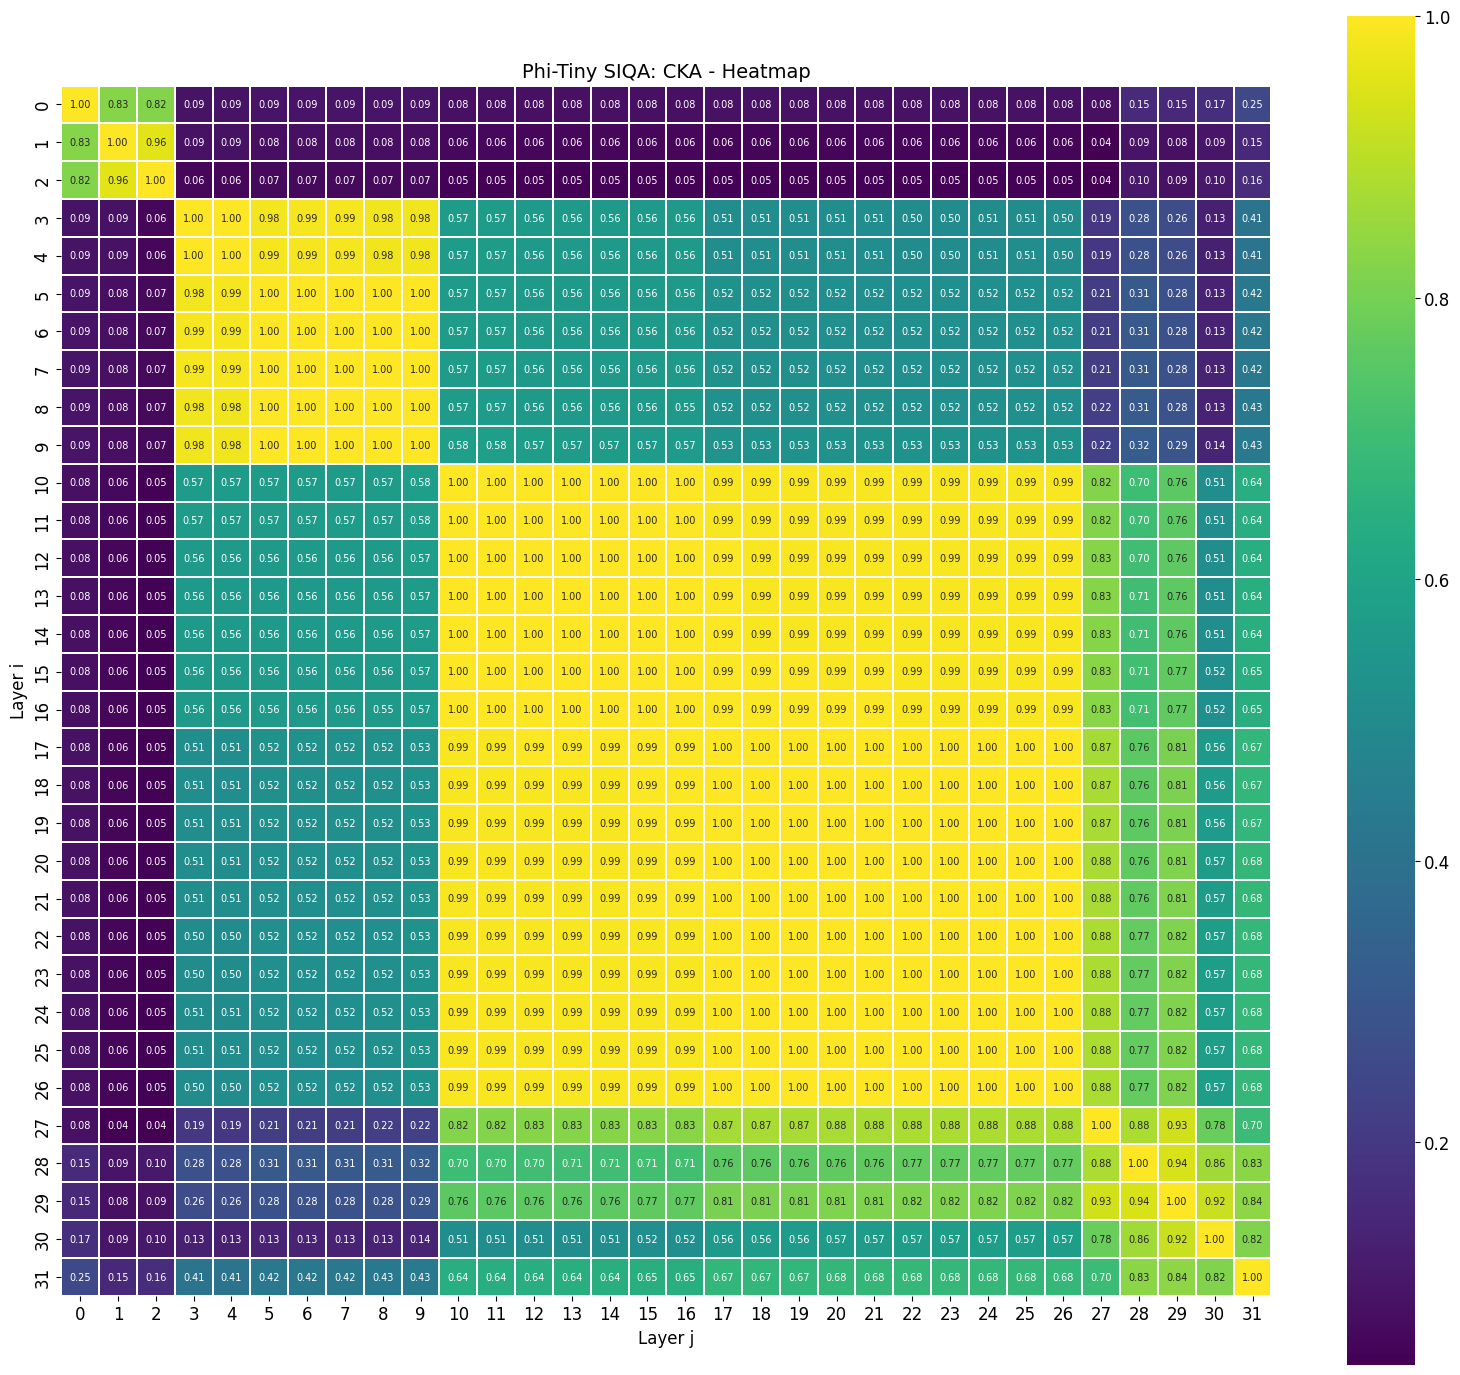

In [41]:
plot_metric_heatmap('CKA', 'metric_04_CKA.csv')

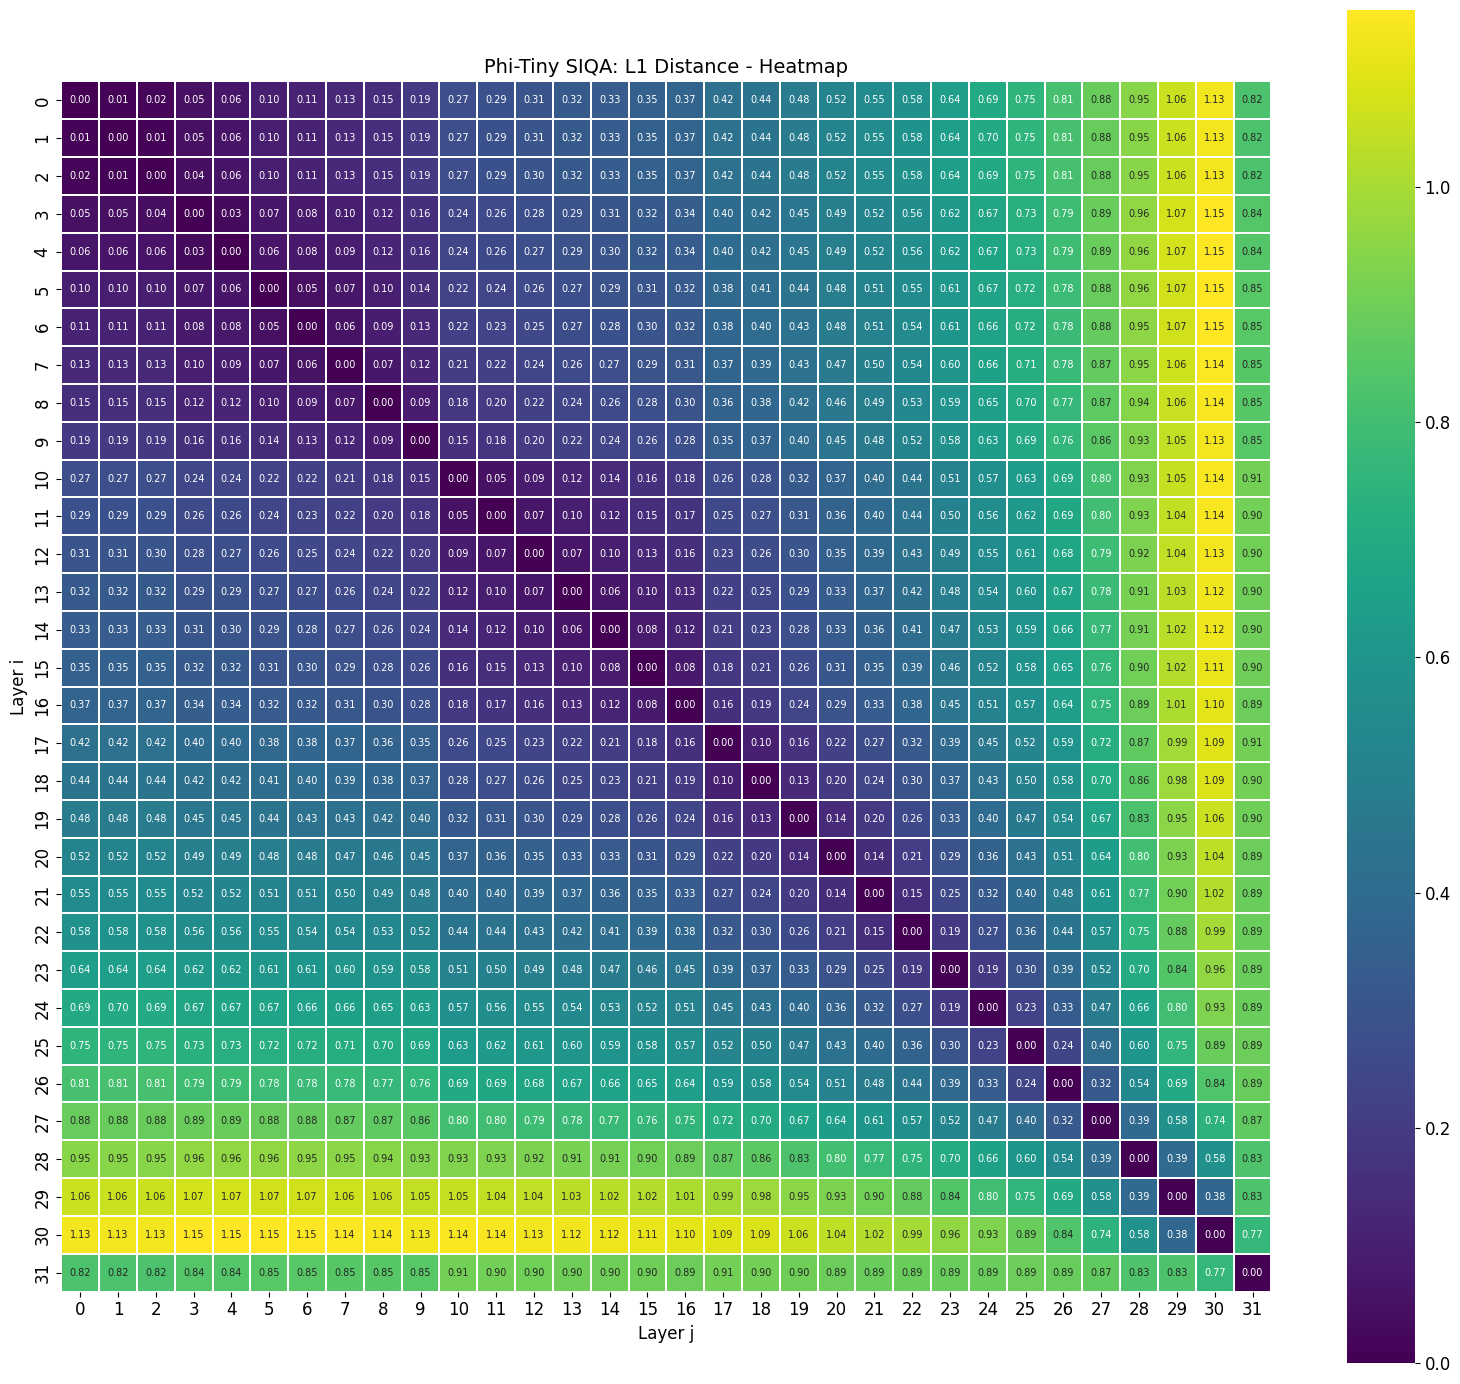

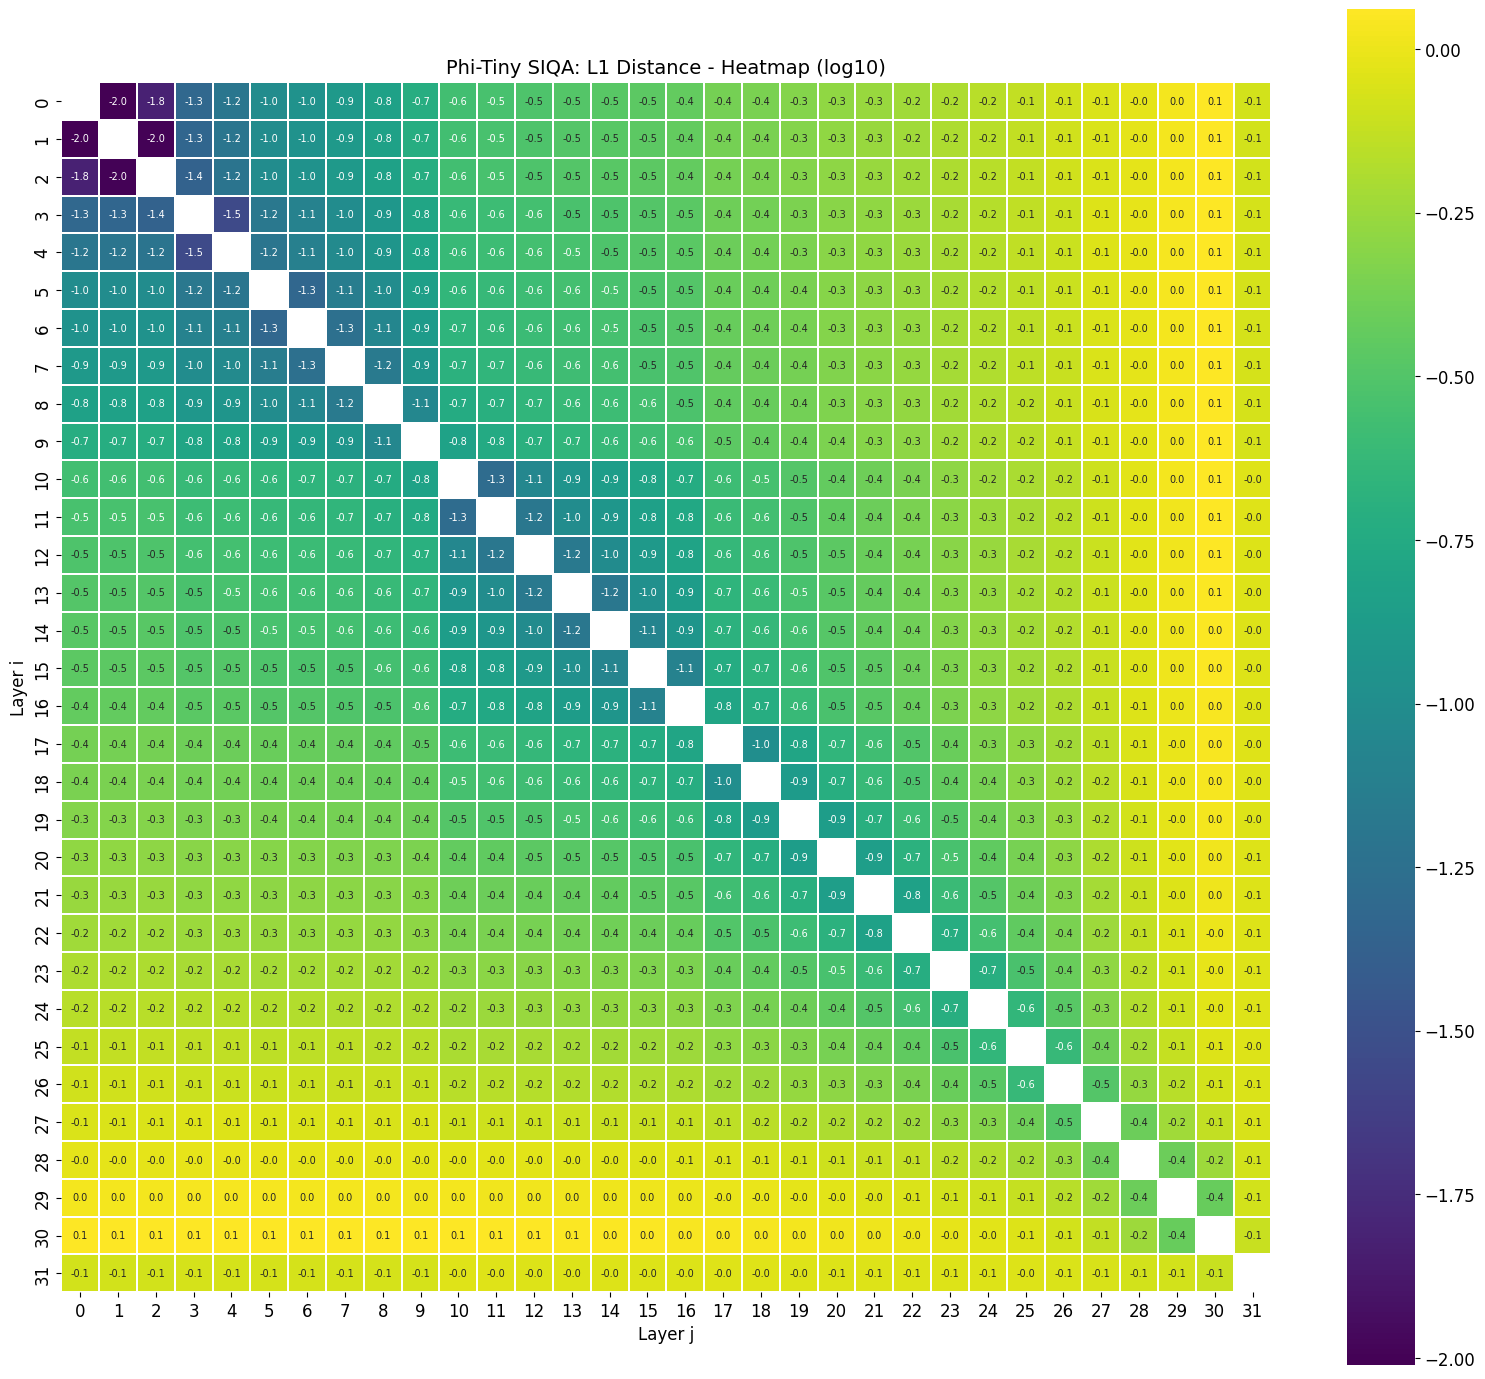

In [42]:
plot_metric_heatmap('L1 Distance', 'metric_05_L1_Distance.csv')
plot_metric_heatmap('L1 Distance', 'metric_05_L1_Distance.csv', use_log=True)

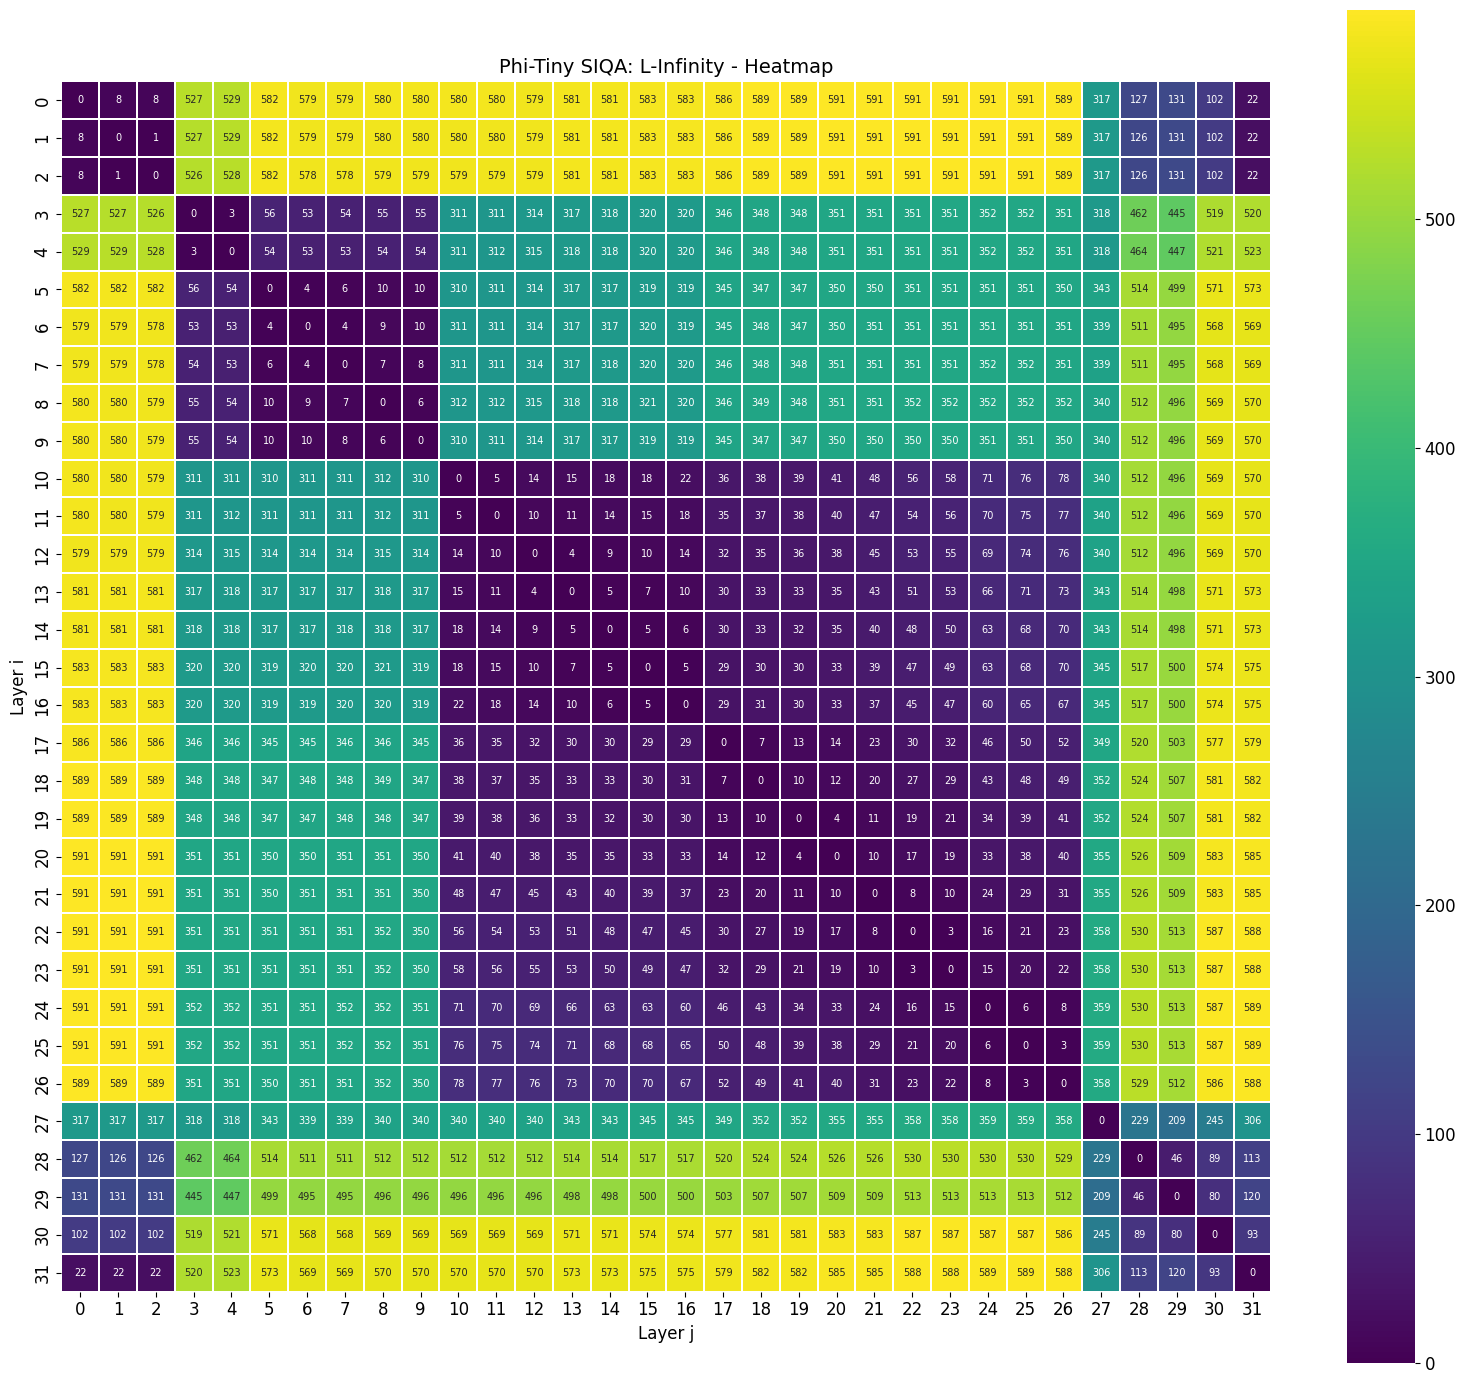

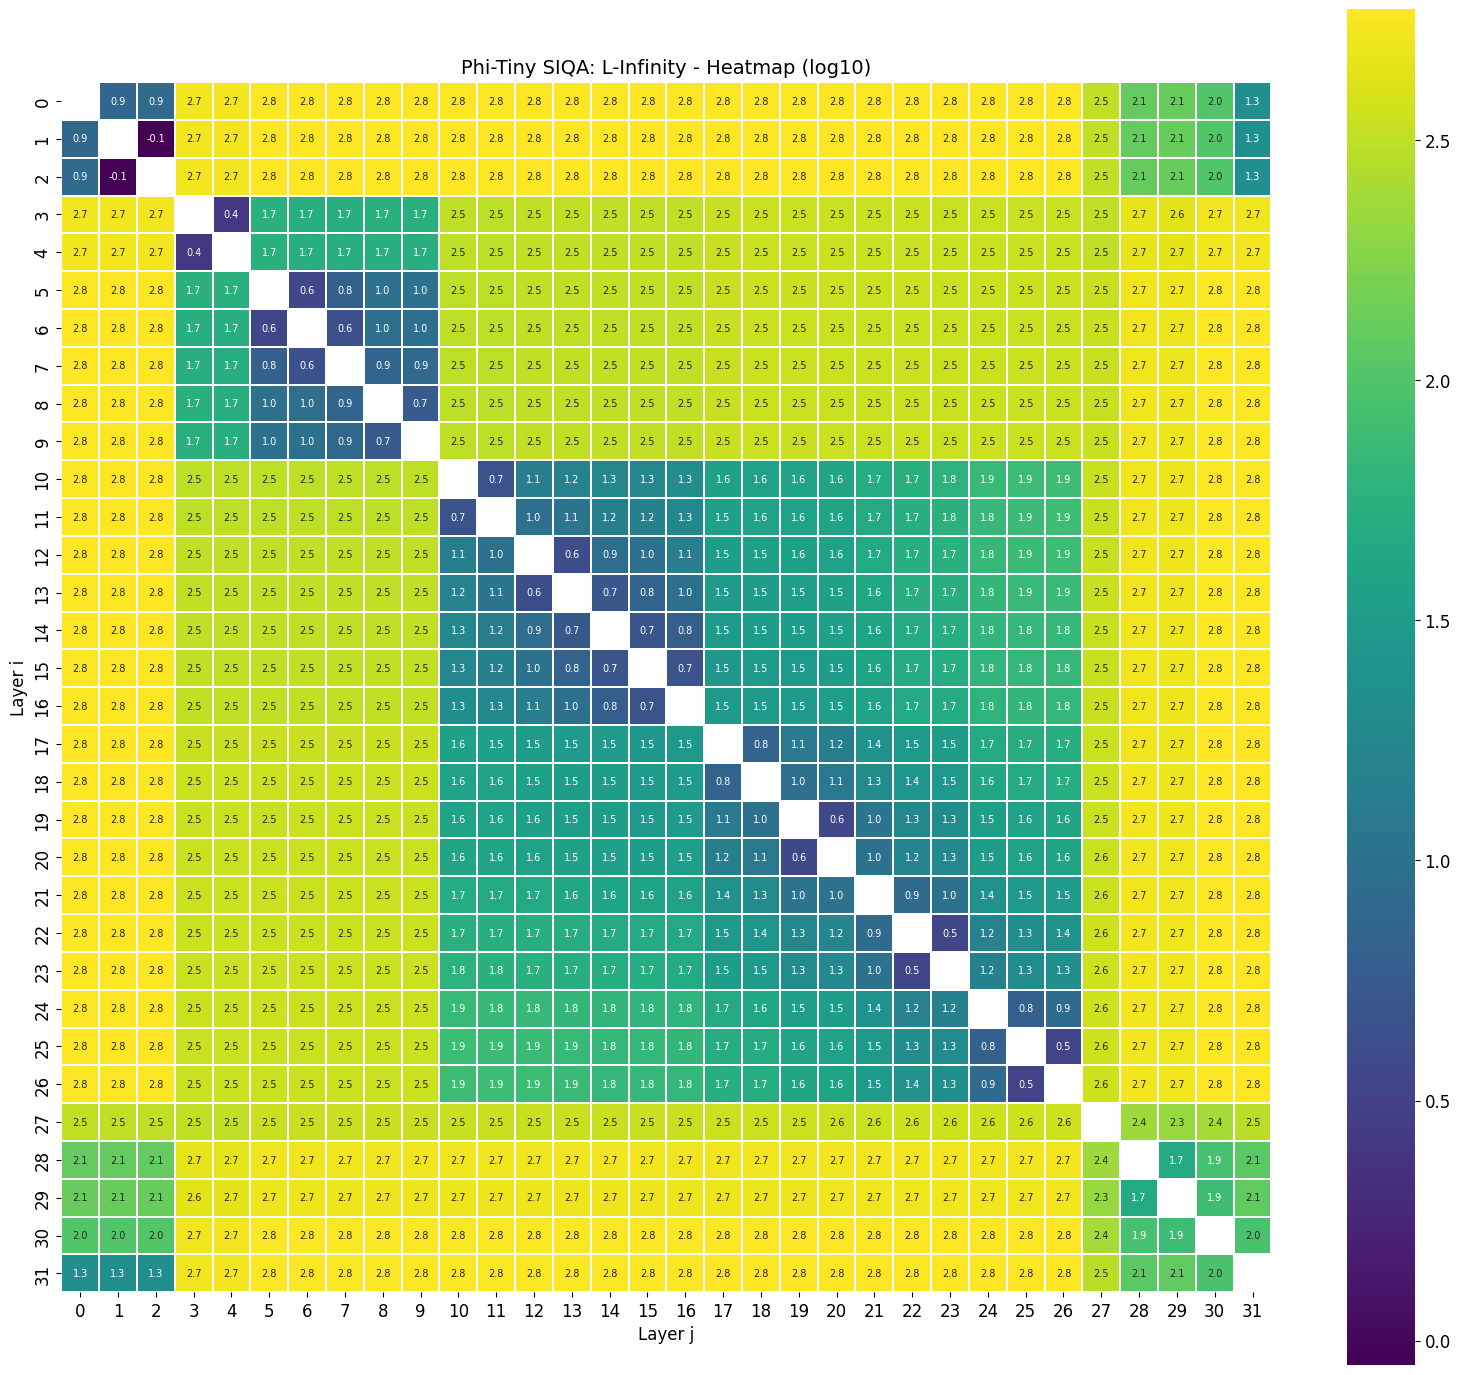

In [43]:
plot_metric_heatmap('L-Infinity', 'metric_06_L_Infinity.csv')
plot_metric_heatmap('L-Infinity', 'metric_06_L_Infinity.csv', use_log=True)

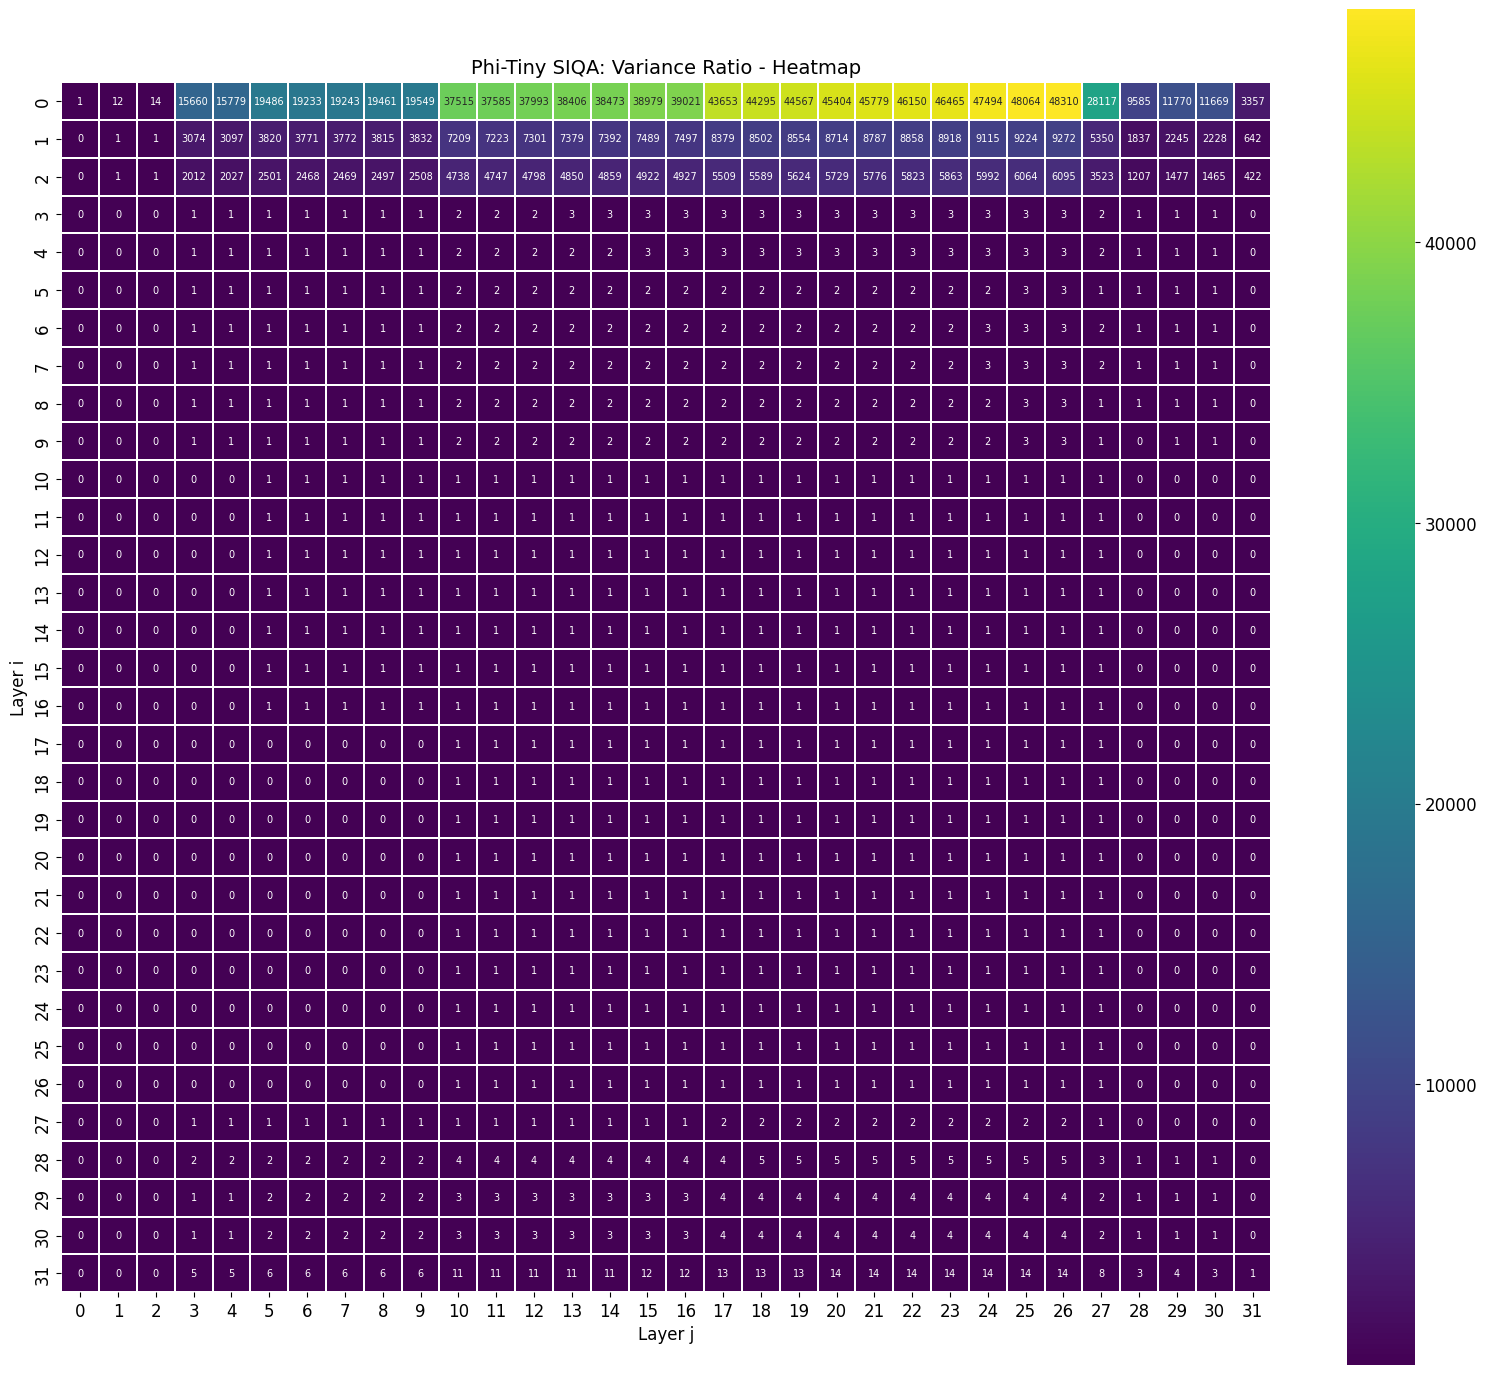

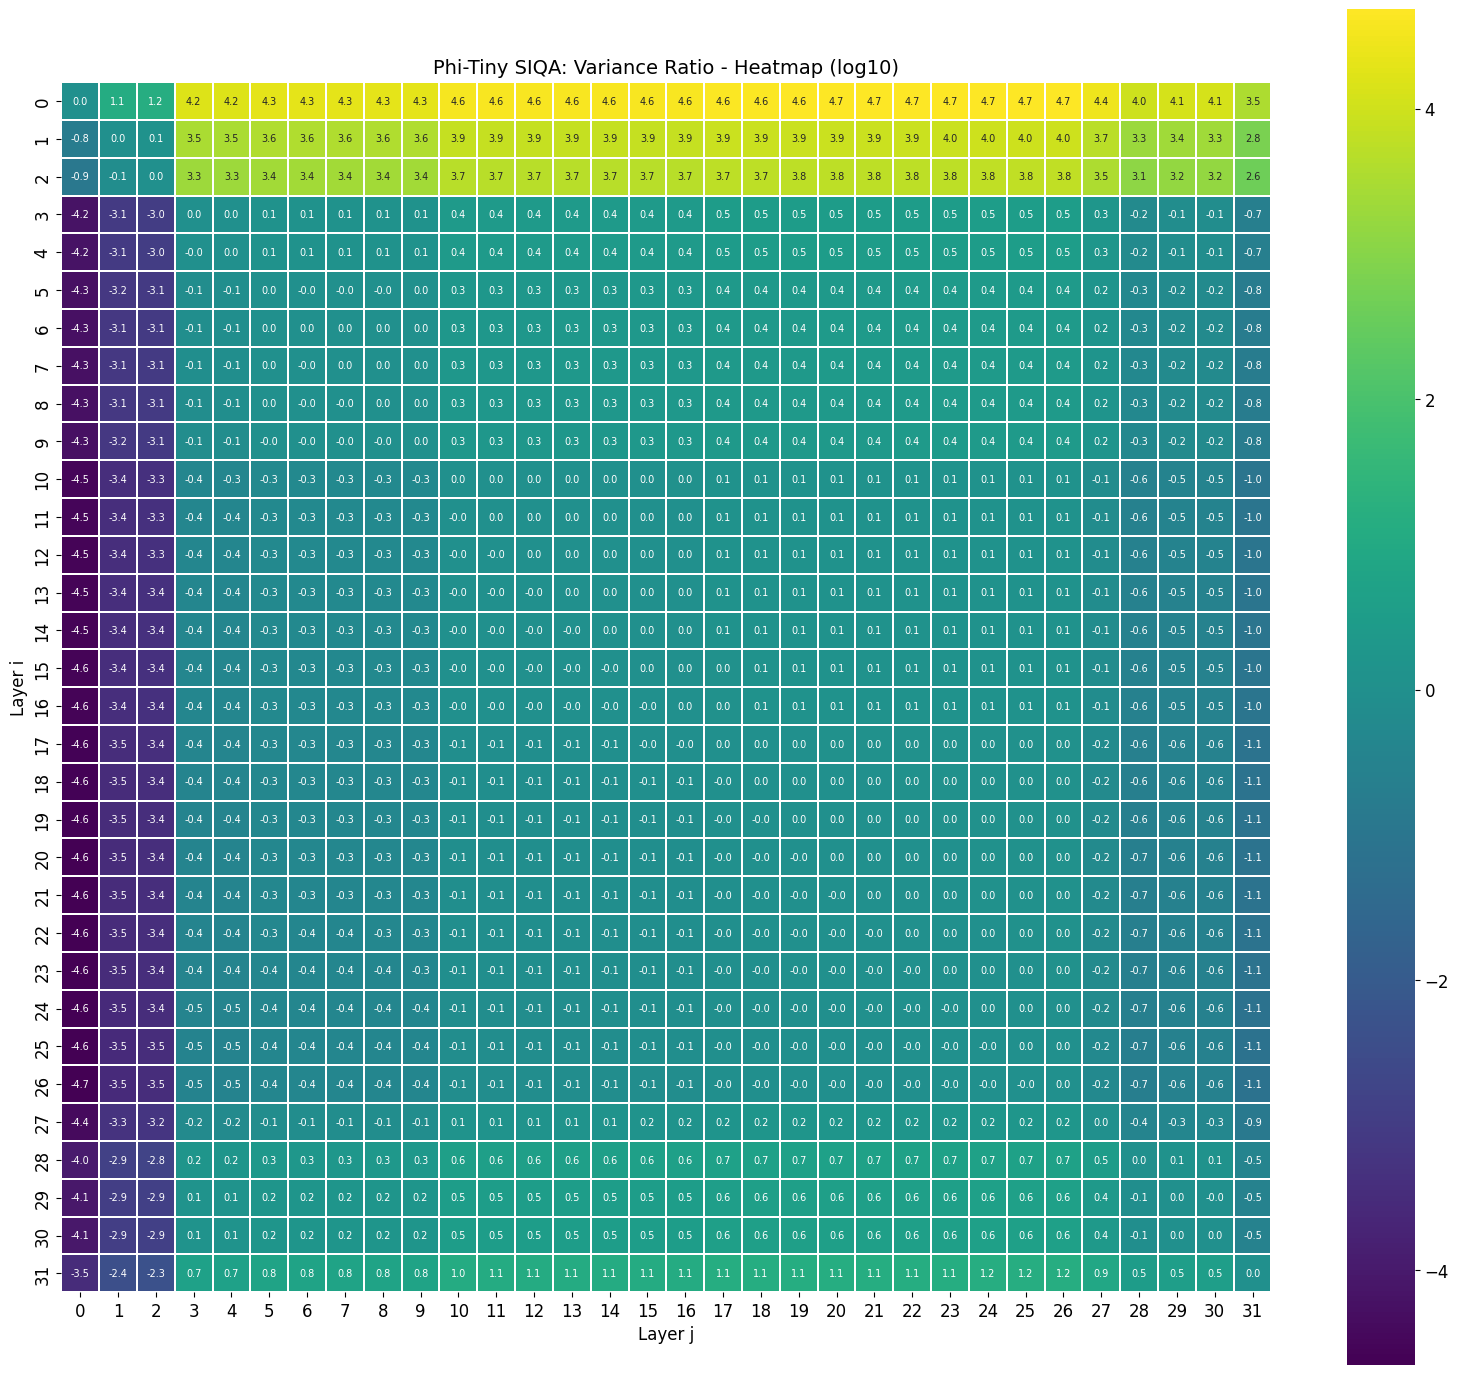

In [44]:
plot_metric_heatmap('Variance Ratio', 'metric_07_Variance_Ratio.csv')
plot_metric_heatmap('Variance Ratio', 'metric_07_Variance_Ratio.csv', use_log=True)

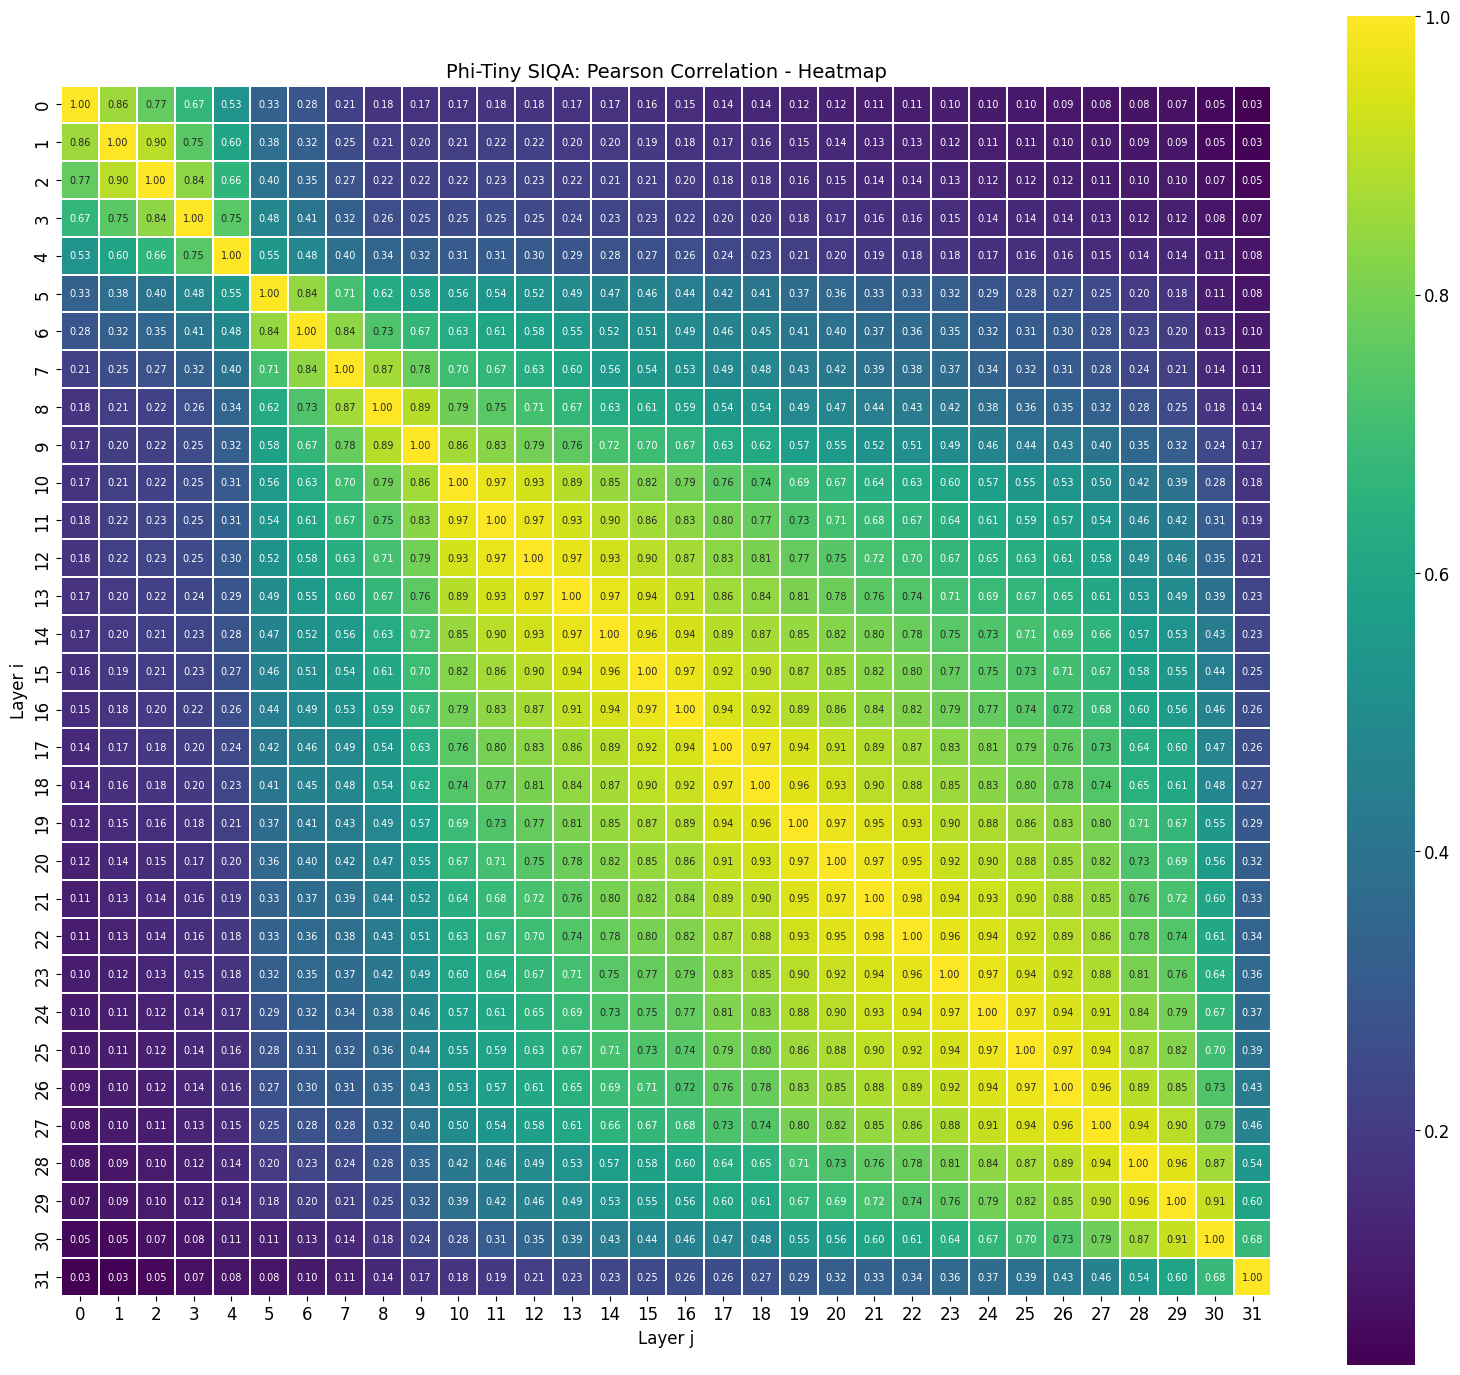

In [45]:
plot_metric_heatmap('Pearson Correlation', 'metric_08_Pearson_Correlation.csv')